# Transformers

The success of deep learning has been driven largely by a small set of core architectures, namely **multilayer perceptrons**, **convolutional networks**, and **recurrent networks**. Despite the impressive progress achieved with these models, their fundamental structure remained closely aligned with much earlier formulations. Although a wide range of methodological improvements enriched the practitioner’s toolkit (such as ReLU activations, residual connections, batch normalization, dropout, and adaptive optimization methods) the underlying architectures can still be understood as **scaled-up and refined versions of classical ideas**. In this perspective, the remarkable advances in deep learning are often attributed less to radically new model designs and more to external factors, in particular the **dramatic increase in computational capabilities**, enabled by parallel hardware such as GPUs, and the **availability of large-scale datasets**, which made it possible to effectively train increasingly expressive models.

However, a new architecture, the [**Transformer**](./papers/(2017)%20-%20Attention%20Is%20All%20You%20Need.pdf), has emerged as a dominant paradigm across a wide range of domains. Initially developed for natural language processing tasks such as machine translation, question answering, and text generation, it has since achieved state-of-the-art performance in areas as diverse as computer vision (e.g., image classification, object detection, segmentation) and spatio-temporal modeling (e.g., weather forecasting, traffic prediction, video understanding). The success of the Transformer stems from its **distinct architectural design**, which abandons both recurrence and convolution in favor of a **self-attention mechanism**. This mechanism enables the model to capture long-range dependencies and model complex, context-dependent interactions between input elements in a flexible and scalable way. Perhaps even more significantly, Transformers introduce a **unified modeling framework**. Once data is expressed in a suitable representation, the same architecture can be applied without substantial modification, regardless of whether the input consists of text, images, audio, or multimodal data. This shift reduces the reliance on specialized architectures tailored to specific modalities (such as convolutions for images or recurrent structures for sequences) and instead promotes a view in which all inputs are mapped into a **shared representation space**, where the model itself learns how to structure and exploit their relationships.

## Input Representation

A Transformer does not operate directly on **raw inputs** such as characters, pixels, or audio samples. Instead, its native input consists of a **sequence of tokens**, each represented by a vector of size D: 

$\displaystyle x_i \in \mathbb{R}^D$ 

By collecting N such tokens and stacking their vector representations row-wise, we obtain the input matrix:

$\displaystyle X \in \mathbb{R}^{N \times D}$

Each column corresponds to one **feature dimension** shared across all tokens

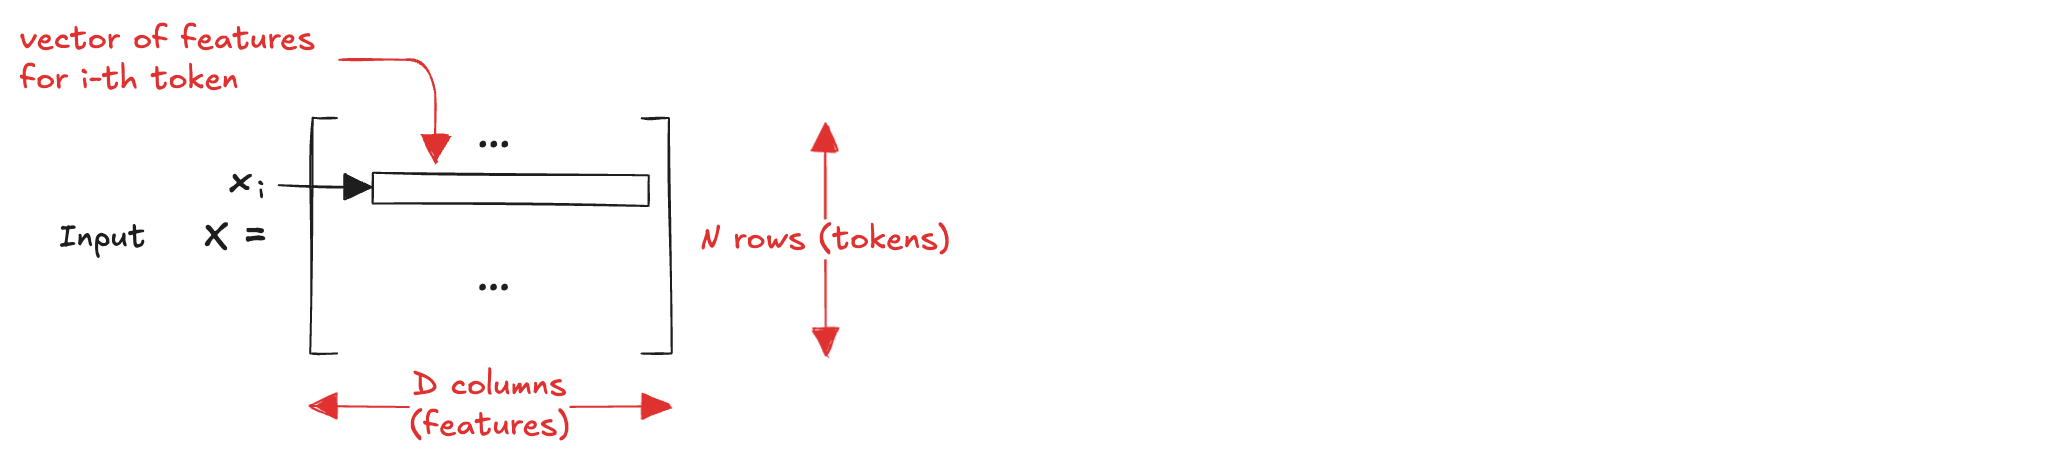

Although this matrix has the same shape as those used in many standard models, its interpretation is fundamentally different. In a typical MLP setting, each row corresponds to an independent data point and each column to an input feature with a fixed, predefined meaning. In a Transformer, instead, **each row represents a token within a single example**, and the columns no longer correspond to explicit features, but to the **coordinates of that token in a shared, learned representation space**. These dimensions do not have an individual semantic interpretation; rather, meaning is encoded collectively across the vector, and is learned from data rather than specified in advance.

The crucial point is that, from the Transformer’s perspective, the input is simply the matrix X. Any modality-specific structure (such as word boundaries in text, spatial locality in images, or time–frequency patterns in audio) m**ust be handled before this stage**. This is achieved by first **tokenizing** the raw signal into discrete units (e.g., words, subwords, image patches, or audio frames), and then **embedding** each unit into a numerical vector. Once the matrix X is constructed, the Transformer operates on it without any explicit knowledge of the original data modality, effectively treating all inputs in a uniform representation space.

### Tokenisation

Tokenisation is not a one-size-fits-all procedure: it depends on both the input modality and the task at hand. The underlying goal, however, remains the same: to transform a structured raw input into a collection of vectors of fixed dimension D, so that the Transformer can process them as a sequence of comparable units and apply the same operations to each of them. What varies across domains is therefore **what is chosen as a token** and **how it is mapped into a vector** representation.

In **text**, the most natural tokens are simply units of a sentence. A straightforward approach is to split a sentence into **words**, but in practice it is often more effective to use **subword** tokenization, where words are decomposed into smaller fragments. This allows the model to represent rare words, inflected forms, or proper names without requiring a separate vocabulary entry for every possible variant. After this segmentation step, each token is mapped to an integer index drawn from a **fixed vocabulary**. From this point onward, the model no longer operates on text, but on sequences of discrete identifiers that can be further transformed into vector representations.

A simple example helps make this idea concrete. Suppose we start from the following **corpus**, that is, a collection of text data used to train or evaluate a model. A corpus typically consists of many sentences (or documents) drawn from some domain, and serves as the source from which the model learns patterns in language.

In [1]:
corpus = [
    "the cat sat on the mat",
    "the cat ate the rat",
    "the rat sat on the mat",
]

We begin by extracting the **vocabulary**, that is, the set of all distinct tokens that appear in the corpus. Each token is then assigned a unique integer identifier, allowing the text to be represented as a sequence of numerical indices that the model can process.

In [2]:
# collection of all words in the corpus
words = []

# extract words from each sentence and add them to the list
for sentence in corpus:
    words.extend(sentence.split())

# remove duplicates and sort
vocab_list = sorted(set(words))

# assign an index to each word
vocab = {}
for idx, word in enumerate(vocab_list):
    vocab[word] = idx

print("Vocabulary:", vocab)

Vocabulary: {'ate': 0, 'cat': 1, 'mat': 2, 'on': 3, 'rat': 4, 'sat': 5, 'the': 6}


Given a new sentence, we can tokenize it by first splitting it into words and then replacing each word with its corresponding integer identifier from the vocabulary, thereby converting the sentence into a sequence of token IDs that the model can process.

In [5]:
# input sentence to be tokenized
sentence = "the cat sat on the mat"

# split the sentence into words
words = sentence.split()

# convert each word to its corresponding id
token_ids = []
for w in words:
    token_ids.append(vocab[w])

print("Sentence:", sentence)
print("Token IDs:", token_ids)
print("N =", len(token_ids), "tokens")

Sentence: the cat sat on the mat
Token IDs: [6, 1, 5, 3, 6, 2]
N = 6 tokens


An **image** can be tokenized by dividing it into non-overlapping patches of size PxP. Each patch contains a number of channels C (e.g., 3 for RGB images), and when the patch is flattened, it is transformed into a vector of length CxPxP.

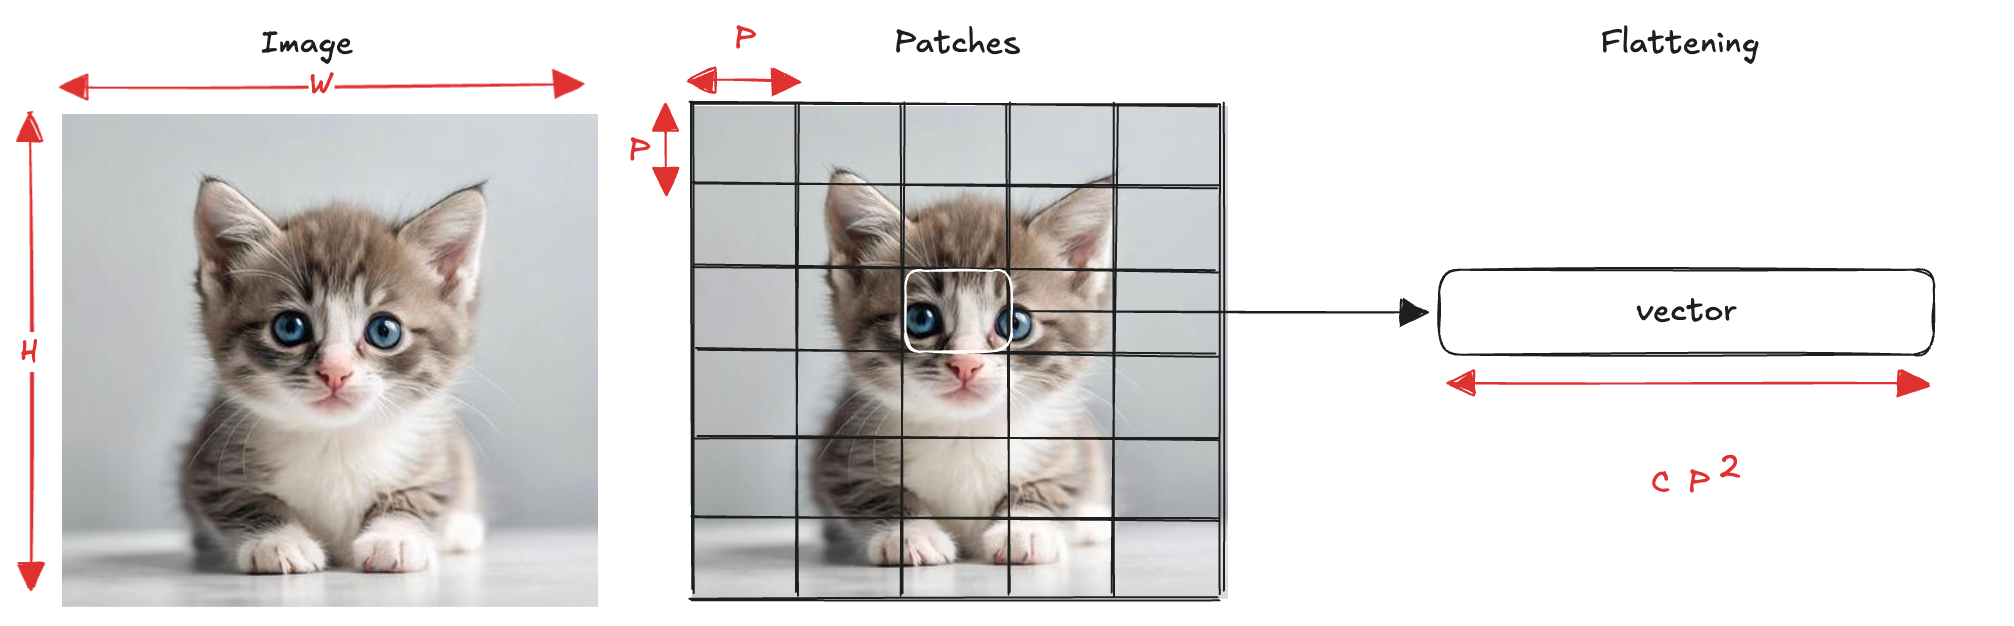

As an example, the following function tokenizes a batch of images by splitting each image into non-overlapping patches using **PyTorch’s unfold operation**. This operation extracts local blocks from the input tensor (effectively “cutting” the image into small regions) without copying data. Each extracted patch is then flattened into a vector, so that the entire image is represented as a sequence of patch vectors that can be fed into the model.

In [6]:
import torch

def image_to_patches(images, P):
    
    # images: (batch, channels, height, width)
    B, C, H, W = images.shape

    # extract non-overlapping patches
    patches = torch.nn.functional.unfold(images, kernel_size=P, stride=P)

    # reshape to (batch, number_of_patches, patch_size)
    patches = patches.transpose(1, 2)

    return patches

In the following example, we construct a dummy batch consisting of two RGB images:

In [7]:
# create a batch of 2 RGB images of size 224x224
images = torch.randn(2, 3, 224, 224)

# define the patch size
P = 16  

# convert images into patches
patches = image_to_patches(images, P)

print("Input shape:", images.shape)
print("Patches shape:", patches.shape)

Input shape: torch.Size([2, 3, 224, 224])
Patches shape: torch.Size([2, 196, 768])


An **audio waveform** is both long and continuous, so there is no natural notion of "token boundaries" as in text. Tokenization therefore requires imposing a segmentation in time, dividing the signal into smaller chunks that are short enough to keep the sequence length manageable, yet long enough to preserve meaningful acoustic patterns such as pitch, formants, or transients.

The simplest approach is known as framing. The waveform is partitioned into segments of fixed length L samples (typically corresponding to 20–40 ms), and successive segments are extracted by sliding a window along the signal by a fixed step H, called the hop size. If H = L, the frames are contiguous and do not overlap. If H < L, consecutive frames overlap, so that part of the signal is shared between neighboring segments, providing a smoother and more redundant representation of the audio.

⸻

Se vuoi una versione ancora più intuitiva (più “didattica”), posso renderla ancora più concreta.

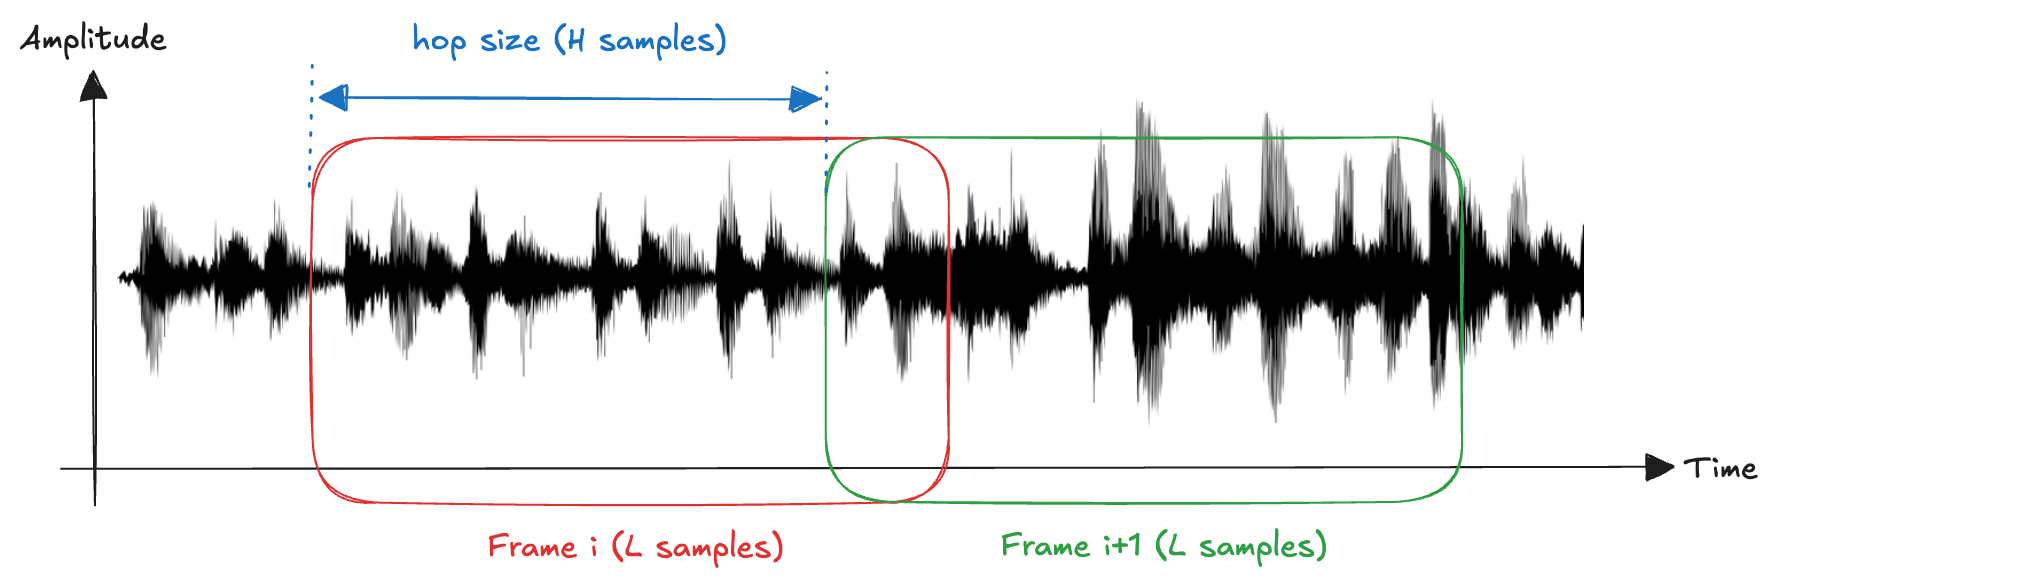

Concretely, given an audio signal x[t], the i.th frame is defined as:

$\displaystyle f_i = x[iH : iH + L] \quad i=0, 1, ..., N-1$

where N is the total number of frames, which depends on the total number of samples T in the signal and the choice of L and H: 

$\displaystyle N = \left\lfloor \frac{T - L}{H} \right\rfloor + 1$

A widely used alternative is to tokenize not the waveform, but a **time–frequency representation**. we first compute a Fourier transform to convert the signal to a **spectrogram**. At that point our signal is a 2D array that we can tokenize exactly like an image. The intuition is that many perceptual cues (pitch, formants, harmonics, onsets) are more linearly separable in a spectrogram than in raw samples, so tokenization becomes "more semantic".

### Embeddings

Tokenisation gives us a collection of discrete units, but it does not yet give us something we can compute with. The role of **embeddings** is to convert each token into a vector in a **shared D-dimensional space**, so that all tokens (regardless of their original modality) **become comparable objects** on which the same machine learning machinery can operate. At a high level, an embedding is just a learned function:

$\displaystyle e: \text{token} \ \longrightarrow\ \mathbb{R}^D$

and applying it to the N tokens produced provide an input matrix:

$\displaystyle X =
\begin{bmatrix}
e(t_1)^\top\\
e(t_2)^\top\\
\vdots\\
e(t_N)^\top
\end{bmatrix}
\in \mathbb{R}^{N\times D}$


The key conceptual point is that embeddings do not merely encode tokens, they **define the geometry** in which it is possible **to measure compatibility**. When two tokens end up with similar embeddings, the model can easily make them attend to similar information, when embeddings are far apart, the model can keep them distinct. We will see several embedding strategies in the examples, but the most common one is to simply learn a **lookup table** that maps each token to a vector. This is the standard approach for text, where we have a fixed vocabulary of tokens of size V and we can learn an embedding matrix of size V×D. For images and audio, we typically use a **learned linear projection** that maps raw pixel values or spectrogram values to the embedding space.

## Attention

Up to this point, every architecture we have discussed has relied (explicitly or implicitly) on the assumption that the **input lives in a fixed, well-defined shape**. In ImageNet classification, for example, we typically resize or crop images to 224x224 pixels, and the network is engineered (and trained) around that convention. In time-series forecasting, the situation is similar: an RNN is fed windows of a predetermined length, so "how much past" the model sees is fixed in advance. This design choice is convenient, but it becomes **a real bottleneck when the input is genuinely variable in size and in information content**. When sequences get long, the difficulty is not merely computational; it is **conceptual**: the model must decide what to retain, what to forget, and how to access something it saw (or produced) many steps ago. In practice, keeping track of "everything so far" becomes increasingly fragile as the context grows.

### Queries, keys and values

A useful contrast is a **database** D. In its simplest abstraction, a database is just a collection of stored items, each addressed by a **key** and carrying a **value**:

$ D = \{(k_1,v_1), (k_2,v_2), \ldots, (k_m,v_m)\}$

For instance, we can consider a database consisting of the last names and first names of a group of people, with the last name as the key and the first name as the value: 

In [6]:
D = {"Zhang": "Aston", 
     "Lipton": "Zachary", 
     "Li": "Mu", 
     "Smola": "Alex", 
     "Hu": "Rachel", 
     "Werness": "Brent"}

We can then **operate on the database** by issuing a **query**. For example, an exact query to retrieve a specific entry:

In [7]:
q = "Li"
print(D[q])  # Output: Mu

Mu


Or an approximate query to retrieve all entries whose key start with a given prefix:

In [8]:
# Approximate match (keys starting with q)
approx = {k: v for k, v in D.items() if k.startswith(q)}
print(f"Approximate matches: {approx}")

Approximate matches: {'Lipton': 'Zachary', 'Li': 'Mu'}


We can imagine more complex queries, such as retrieving the top-k entries most similar to a given text, or retrieving all entries that satisfy some logical condition. The crucial point is that **the size of the database can vary freely** (we can add or remove entries), however the **query mechanism is stable** (we do not need to change the way we query it). 

### Attention pooling

Even though the example is intentionally simple, it surfaces several important ideas. The first is that we can formulate a query as an operation on key–value pairs in a way that does **not depend on the database size**: the same mathematical object still makes sense whether the database contains a handful of items or millions. The second is that the very **same query can legitimately produce different outputs**, because the answer is not "hard-coded" in the procedure but is induced by the current contents of the database. The third is that operating over an enormous state space **does not require complicated code**: the mechanism can be as elementary as exact lookup, approximate matching, or retrieving the top-k most relevant entries, with the **complexity pushed into the representation and the similarity score** rather than into bespoke control logic. Finally, and perhaps most importantly, none of this requires **compressing or simplifying the database** just to make retrieval workable: we can keep a large collection of stored information and still read from it effectively by learning how to address it. This perspective leads directly to one of the most influential architectural ideas of the last decade: the [**attention mechanism**](./papers/(2014)%20-%20Neural%20machine%20translation%20by%20jointly%20learning%20to%20align%20and%20translate.zip), which can be defined as:

$\displaystyle A(q,D) = \sum_{i=1}^m a(q,k_i) \, v_i$

Here the terms a() are **scalar attention weights** that quantify how strongly the query matches each key. The term attention is natural: the mechanism assigns large weights only to a small subset of entries, and the output is therefore dominated by the corresponding values, those are the items the model is effectively "paying attention" to. Operationally, attention reads from the database by producing a weighted linear combination of the stored values:

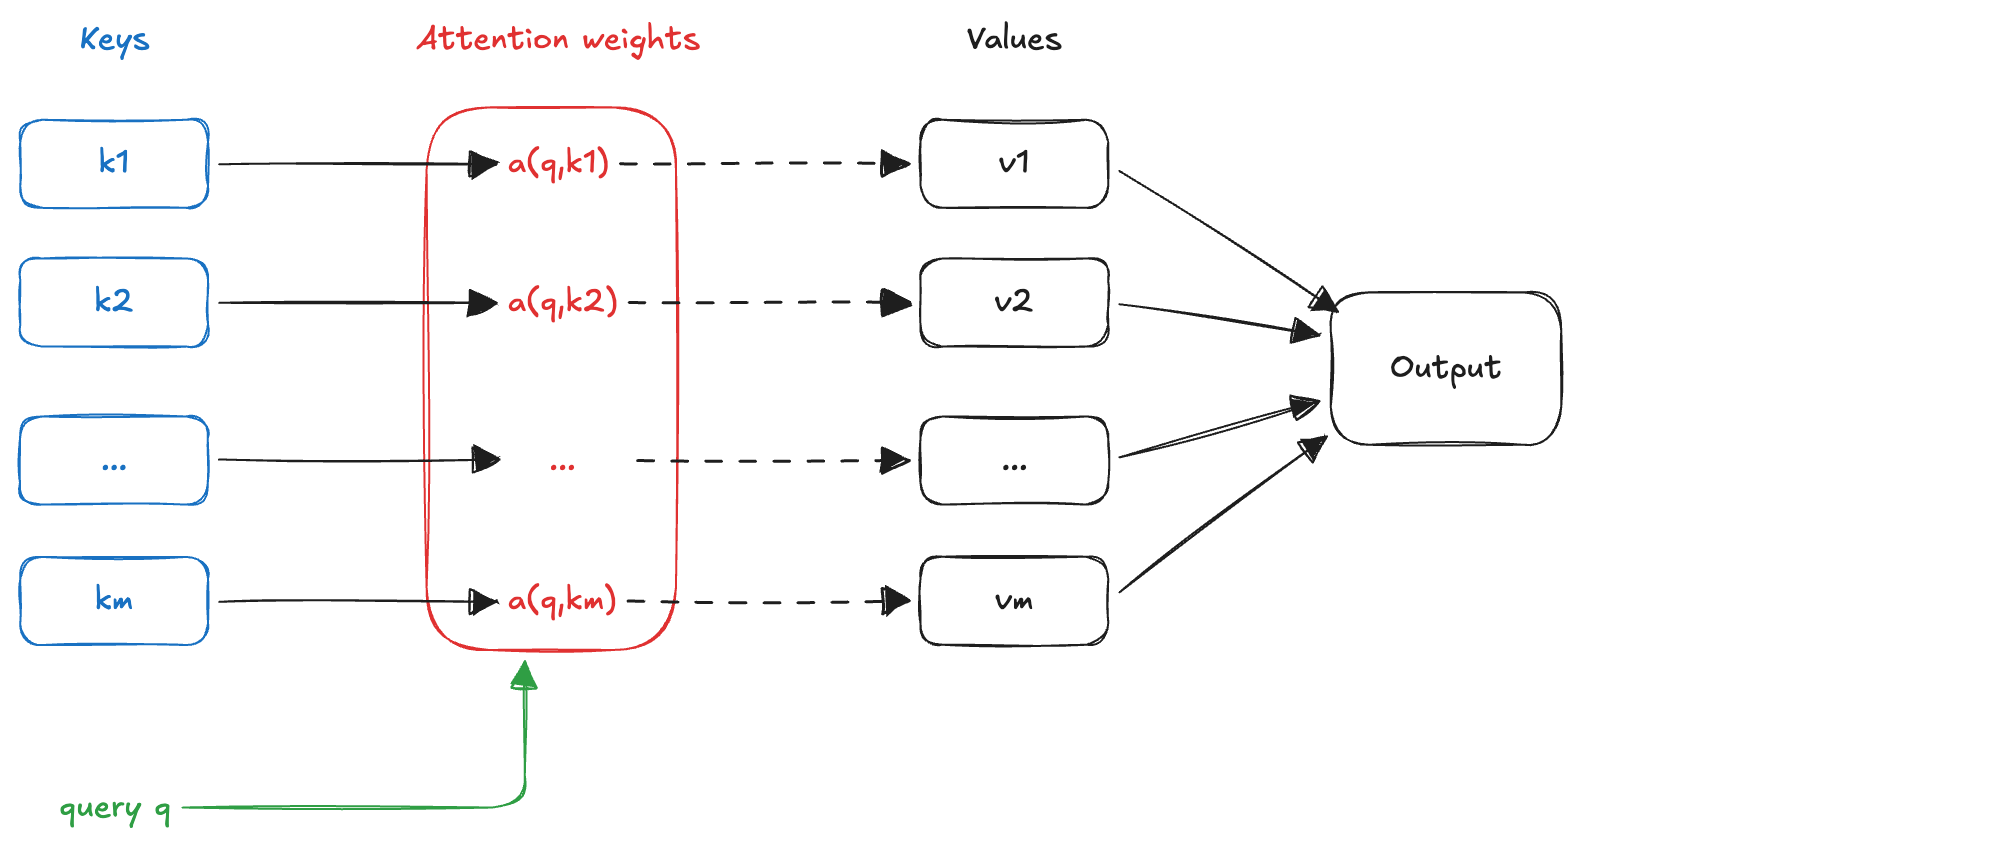

This operation (computing a weighted sum of values guided by how well the query matches each key) is called **attention pooling**. Like other pooling operations, it aggregates information, but here the aggregation is adaptive, shaped by the query rather than fixed in advance. The earlier exact-lookup example is recovered as a limiting case: if one key matches perfectly, its weight becomes 1 while all others go to 0, and the sum collapses to the single retrieved value. Several useful special cases follow from different choices of weights and similarity scores.

A natural next step is to **constrain** the weights so that they behave like a genuine "allocation of attention" across the database. Formally, we require **nonnegativity**:

$\displaystyle a(q,k_i) \ge 0 \quad \text{for all } i$

in order to prevents a pathological kind of retrieval in which the mechanism would "anti-attend" to an item by subtracting its value from the result. In a memory-reading interpretation, negative coefficients have no clear meaning: when we look something up, we may ignore an entry, but we do not retrieve "minus that entry". Then we also require **sum-to-one**:

$\displaystyle \sum_{i=1}^m a(q,k_i)=1$

to provide the weights the semantics of a distribution over entries: the mechanism must decide **how to spread a fixed budget of attention** across the keys. So attention cannot arbitrarily amplify the magnitude of the output just by scaling all weights up (the overall "gain" is controlled).

A common strategy to enforce these constraints is to apply a softmax function to a nonnegative and unnormalized score s(q,k_i) that measures the similarity between the query and each key:

$\displaystyle a(q,k_i) = \frac{\exp(s(q,k_i))}{\sum_{j=1}^m \exp(s(q,k_j))}$

### Interpretability

One reason attention is so appealing is that it often **looks interpretable**. When the weights are constrained to be nonnegative and to sum to one, they behave like **a distribution of "how much attention" the model allocates to each key**. In that setting, a large weight suggests that the corresponding entry is highly relevant to the current query, while small weights indicate entries that are mostly ignored. This picture is useful because it lets us reason about attention as a soft, content-based selection mechanism, something closer to "looking up what matters" than to applying an opaque black-box transformation. That said, it is important to keep the right mental model: **these weights are not an explanation provided by the network**, they are simply an internal computation that happens to admit an intuitive reading. They can align with what we would consider "relevance", but they do not have to. Still, because attention produces an explicit pattern of weights over keys, we can often learn a lot by visualizing how those weights change when we vary the query.

For this purpose we define a **show_heatmap** function to visualize attention weights as a heatmap, with queries on the vertical axis and keys on the horizontal axis:

In [9]:
import matplotlib.pyplot as plt

def show_heatmap(matrix, xlabel, ylabel, title=None):

    fig, ax = plt.subplots(figsize=(5, 5))

    pcm = ax.imshow(matrix.detach().numpy())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    fig.colorbar(pcm, ax=ax, shrink=0.6)
    plt.show()


As a quick sanity check let’s visualize the identity matrix, representing a case where the attention weight is 1 only when the query and the key are the same:


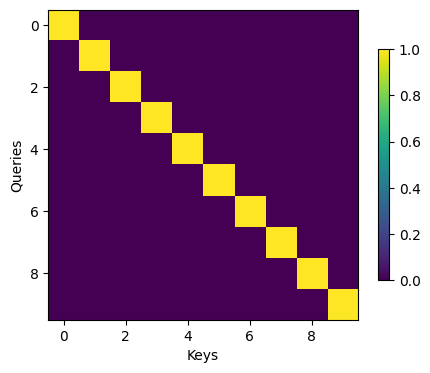

In [10]:
import torch
attention_weights = torch.eye(10)
show_heatmap(attention_weights, xlabel='Keys', ylabel='Queries')

What is remarkable about the attention mechanism is the mismatch between the **simplicity of the computation** and **the size of the space it operates on**. The "code" we execute (the query and its matching rule) can remain extremely concise, even when the set of keys and values is huge. For a neural network layer, this is an attractive property: the mechanism does not need a large number of learned parameters, instead it reuses the same similarity computation to address a potentially vast memory. Of course, when m is large we still have to compute many similarity scores and many weights. This is a runtime cost in computation and memory that grows with m. However, it is not a parameterization cost: the model is not gaining additional degrees of freedom as the database grows, because the weights are produced on the fly by the same fixed, learned matching rule rather than being learned as independent parameters Equally important, **the procedure does not have to be redesigned as the database grows**. Attention applies the same pooling operation regardless of whether there are tens or millions of entries: increasing the database size simply means there are more candidates to compare against, not that the form of the computation changes. In this sense, attention provides a scalable, size-agnostic way to retrieve and aggregate information.

## Scoring functions

An attention layer is essentially specified once we decide **how to score the match between a query and a key**. Everything else follows a fixed and reusable recipe. For each key we first compute a compatibility score, which answers the question "how relevant is this entry for the current query?". We then turn the set of raw scores into attention weights by applying a softmax, so that the weights are nonnegative and sum to one. Finally, we read from the database by taking a weighted average of the values:

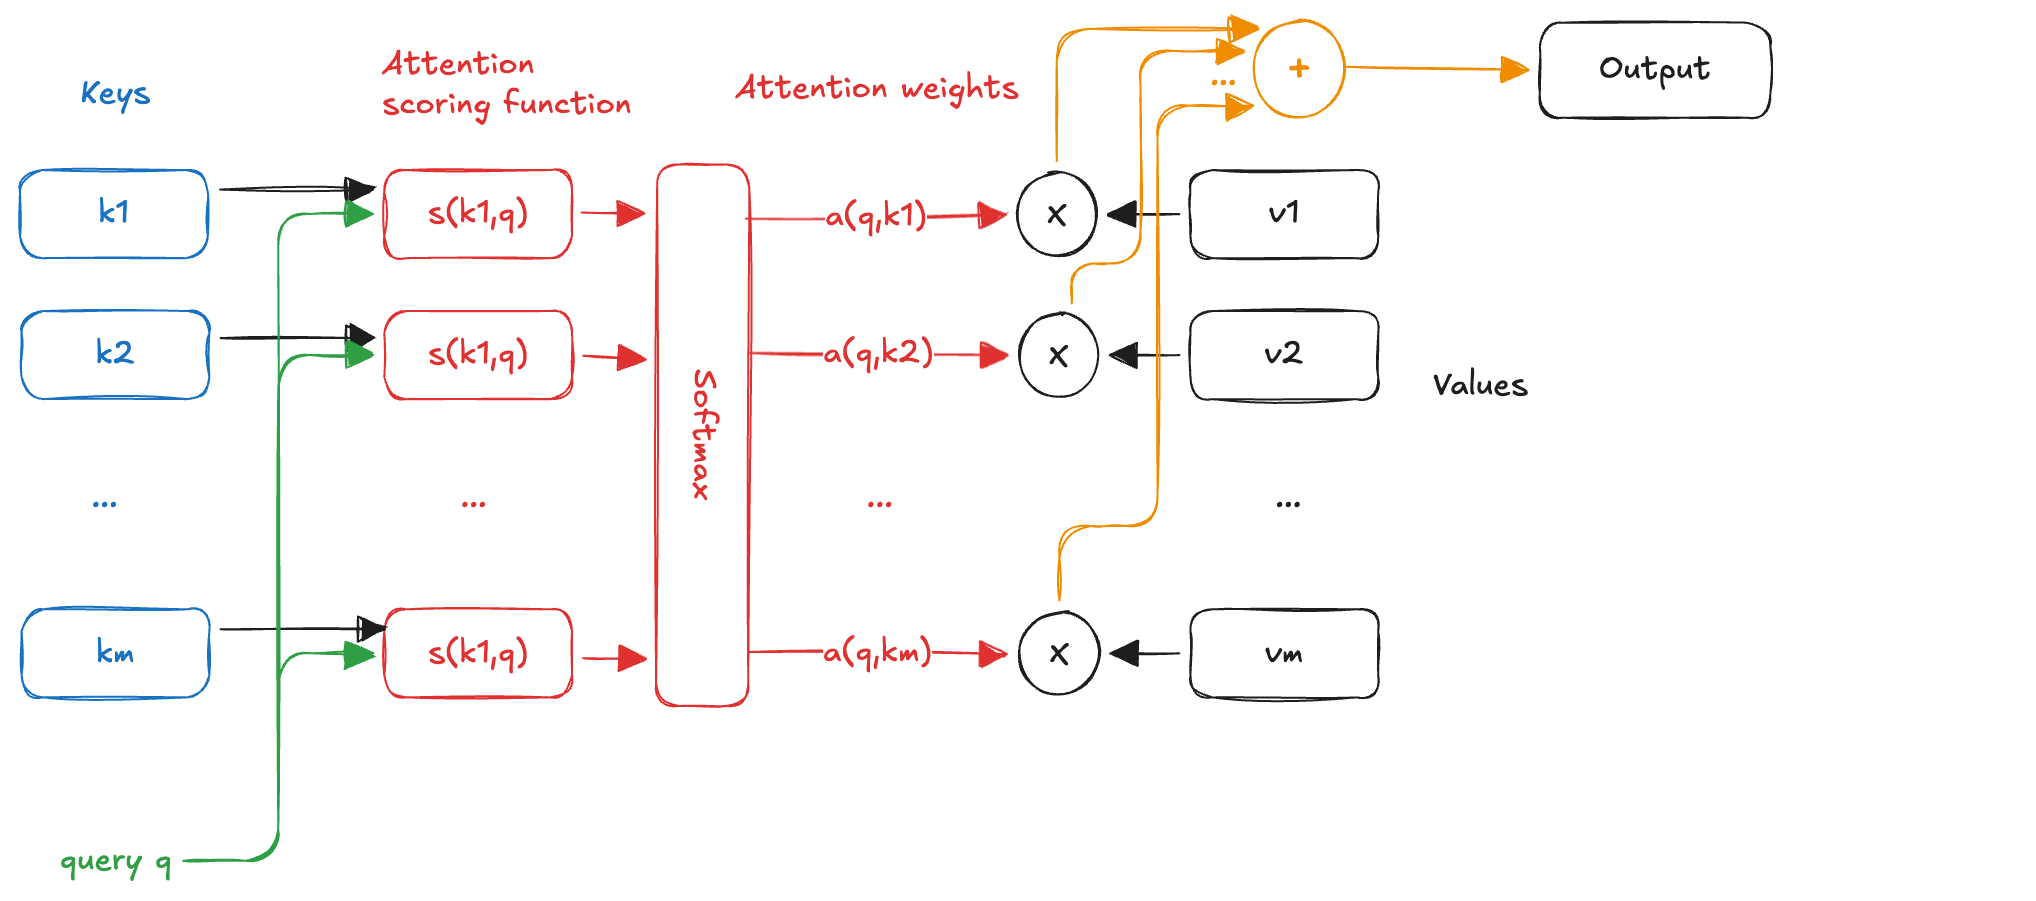

This is precisely the purpose of the **scoring function**:

$\displaystyle s(q, k)$

which takes a query and a key and returns a single scalar measuring their compatibility. A conceptually simple way to build such a score is to start from **distance**: 

$\displaystyle d(q,k)=\lVert q-k\rVert^2$

and convert it into a similarity score by negating (and often scaling) it:

$\displaystyle s(q, k) = -\lVert q-k\rVert^2$

This matches the intuition "closer means more relevant" in the most literal way. However, while it is easy to interpret, **it is not the most efficient choice computationally**. Computing norms and distances tends to be more costly than the primitive that modern hardware accelerates extremely well: matrix multiplications and dot products. For this reason, most deep learning attention mechanisms adopt scoring functions built around dot products, which are cheaper to evaluate and integrate naturally into highly optimized linear-algebra pipelines.

### Scaled Dot-Product score

The distance-based score can be rewritten in a way that makes the connection to dot products more explicit:

$\displaystyle s(q, k) = - \lVert q-k\rVert^2 = -\|q\|^2 - \|k\|^2 + 2 q^\top k$

The first term depends only on the query and it is the same for every key, so it does not affect the relative ordering of scores across keys and it can be safely dropped without changing the resulting attention distribution. In other words, this term is a constant offset that shifts all scores by the same amount, but it does not change their relative proportions after normalization:

$\displaystyle s(q, k) = - \|k\|^2 + 2 q^\top k$

In many networks, activations are deliberately kept well-scaled. Batch normalization and layer normalization tend to produce representations with bounded norms. In that regime, the term $-\|k\|^2$ contributes mostly a small, nearly constant offset and has limited influence on which keys win the competition. Dropping it typically changes little about the qualitative behavior:

$\displaystyle s(q, k) = 2 q^\top k$

The factor of 2 is a constant rescaling that does not affect the softmax output and can be removed. One final detail matters for stability. The dot product tends to grow in magnitude with the dimensionality of the vectors:

$\displaystyle q \in \mathbb{R}^d, \quad k \in \mathbb{R}^d$

To see why, assume (as a rough model) that the components of q and k are independent and identically drawn random variables with zero mean and unit variance. Then the dot product has zero mean and variance proportional to d. If we feed such scores into the softmax function, growing variance quickly makes the distribution either extremely peaky (one key gets almost all the mass) or numerically unstable. To keep the scale of the scores roughly independent of dimension, we use **scaled dot-product score** dividing by square root of the dimensionality, as introduced in the original Transformers paper:

$\displaystyle s(q,k) = \frac{q^\top k}{\sqrt{d}}$

We can implement a batch version of this function as follows using PyTorch:

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class ScaledDotProductAttention(nn.Module):
    
    def __init__(self):
        super().__init__()

    # queries : (batch, num_queries, d)
    # keys    : (batch, num_keys,    d)
    # values  : (batch, num_keys,    d_v)
    def forward(self, queries, keys, values):  

        # Find the dimension of the queries/keys  
        d = queries.shape[-1]

        # Compute the attention scores
        scores = queries @ keys.transpose(-2, -1) / (d ** 0.5)

        # Normalize the scores to obtain attention weights
        self.weights = F.softmax(scores, dim=-1)

        # return the weighted sum of the values
        return self.weights @ values        

However, We are implicitly assuming that queries and keys live in the same vector space (they have the **same dimensionality**). In many situations, however, this is an unnecessary restriction. For instance, we may want to use a query coming from one representation to search keys coming from another representation with a different dimensionality. The underlying idea of attention (score each key, normalize, then take a weighted sum of values) still makes perfect sense, it is only the dot product that becomes ill-defined. To overcome this issue, a simple and widely used remedy is to **learn two projections** that map queries and keys into a shared space of a new dimension h, and to perform the matching there:

$\displaystyle s(q,k) = \frac{(W_q q)^\top (W_k k)}{\sqrt{h}}$

where 

$\displaystyle W_q\in\mathbb{R}^{h\times d_q}$ 

and 

$\displaystyle W_k\in\mathbb{R}^{h\times d_k}$ 

This fixes the dimension mismatch and generalizes the dot-product attention.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GeneralizedScaledDotProductAttention(nn.Module):

    def __init__(self, d_q, d_k, h):
        super().__init__()
        self.W_q     = nn.Linear(d_q, h, bias=False)   # projects queries into R^h
        self.W_k     = nn.Linear(d_k, h, bias=False)   # projects keys    into R^h
        self.h       = h

    # queries : (batch, num_queries, d_q)
    # keys    : (batch, num_keys,    d_k)
    # values  : (batch, num_keys,    d_v)   ← d_v is unrestricted
    def forward(self, queries, keys, values):

        q = self.W_q(queries)                               # (batch, num_queries, h)
        k = self.W_k(keys)                                  # (batch, num_keys,    h)

        scores       = q @ k.transpose(-2, -1) / (self.h ** 0.5)
        self.weights = self.dropout(F.softmax(scores, dim=-1))

        return self.weights @ values                        # (batch, num_queries, d_v)


### Additive score

Additive score takes the same idea to project query and keys into a shared space idea, but it replaces the dot product by a learned **compatibility function**. Instead of comparing the two projected vectors by multiplying them, we first combine them by addition and let a nonlinearity shape their interaction:

$\displaystyle s(q,k) = w^\top \tanh\!\big(W_q q \;+\; W_k k \;+\; b\big)$

where 

$\displaystyle b\in\mathbb{R}^{h}$ 

$\displaystyle w\in\mathbb{R}^{h}$

This construction can learn a **richer notion of "match"** than pure alignment. An interpretation is that the query and key are concatenated and fed into an MLP with a single hidden layer.

In [13]:
import torch.nn as nn

class AdditiveAttention(nn.Module):
    def __init__(self, d_q, d_k, h):
        super().__init__()
        self.W_q = nn.Linear(d_q, h, bias=True)
        self.W_k = nn.Linear(d_k, h, bias=False)
        self.w_o = nn.Linear(h, 1,  bias=False)

    # queries : (batch, num_queries, d_q)
    # keys    : (batch, num_keys,    d_k)
    # values  : (batch, num_keys,    d_v)
    
    def forward(self, queries, keys, values):
        
        q = self.W_q(queries).unsqueeze(2) # (batch, num_queries, 1, h)
        k = self.W_k(keys).unsqueeze(1) # (batch, 1, num_keys, h)
        scores = self.w_o(torch.tanh(q + k)).squeeze(-1)  # (batch, num_queries, num_keys)
        self.weights = F.softmax(scores, dim=-1)
        return self.weights @ values         # (batch, num_queries, d_v)

Attention scoring functions are effective tools for aggregating across sequences of variable length. In particular, the dot product attention is the mainstay of modern Transformer architectures. When queries and keys have different dimensionalities, both the generalized dot-product and additive scoring functions handle this naturally by projecting into a shared space before computing the score. Optimizing these layers is one of the key areas of advance in recent years (e.g. see the [NVIDIA Transformer Library](https://docs.nvidia.com/deeplearning/transformer-engine/user-guide/index.html)).

## Multi-head attention

Given the same set of queries, keys, and values we may want to combine knowledge from different behaviors of the same attention mechanism, such as capturing dependencies of various ranges (e.g., shorter-range vs. longer-range) within a sequence. Thus, it may be beneficial to allow the attention mechanism to jointly use different representation subspaces of queries, keys, and values. To this end, instead of performing a single attention pooling, queries, keys, and values can be transformed with independently learned linear projections. 

Then these  projected queries, keys, and values are fed into attention pooling in parallel. In the end,  attention-pooling outputs are concatenated and transformed with another learned linear projection to produce the final output. This design is called multi-head attention, where each of the 
attention pooling outputs is a head. Using fully connected layers to perform learnable linear transformations,

## Machine Translation

The abstract machinery developed so far (queries, keys, values, scoring functions) is most compelling when applied to a concrete problem that clearly shows the need for a flexible, size-agnostic mechanism to retrieve and aggregate information. Machine translation is exactly that problem: **given a sentence in a source language, the goal is to produce a semantically equivalent sentence in a target language**. Both the input and the output are variable-length sequences, and there is no fixed positional correspondence between their elements. Many problems have this flavor of **mapping between two such "unaligned" sequences**. 

### Preprocessing

As a concrete instance of this task, we work with the **English–Italian dataset** from the [**Tatoeba Project**](https://tatoeba.org/), a crowd-sourced collection of bilingual sentence pairs.

In [14]:
import urllib.request
import zipfile 
import os

# Define the URL of the dataset
url = "https://www.dropbox.com/scl/fi/csvxhe8q50h7fwa67p7bh/eng-ita.zip?rlkey=y7m93phovbbdadg00l02yau65&st=fl7bpvvf&dl=1"

# Create data directory if it does not exist
os.makedirs("./data", exist_ok=True)

# Prepare data if not already existing 
if not os.path.exists("./data/eng-ita.zip"):
   print("Downloading dataset...")

   # Download the dataset
   u = urllib.request.urlopen(url)
   data = u.read()
   u.close()

   # Save the dataset to a local file
   with open("./data/eng-ita.zip", "wb") as f :
      f.write(data)

   # Extract the dataset
   with zipfile.ZipFile("./data/eng-ita.zip","r") as zip_ref:
      zip_ref.extractall("./data")
    
else:
   print("Dataset already exists. Skipping download.")

Dataset already exists. Skipping download.


Each example in the dataset consists of a tab-separated pair of an English source sequence and its Italian translation, accompanied by a CC-BY attribution field that we discard.

In [15]:
import pandas as pd

# Load the English–Italian sentence pairs into a Pandas DataFrame
eng_ita = pd.read_csv("./data/ita.txt", sep="\t", header=None,
                   names=["english", "italian", "attribution"],
                   encoding="utf-8")

# Drop the attribution column (CC-BY licence metadata, not needed for training)
eng_ita = eng_ita.drop("attribution", axis=1)

# Drop duplicate pairs
eng_ita = eng_ita.drop_duplicates()

# Reset index after deduplication
eng_ita = eng_ita.reset_index(drop=True)

# Show some statistics about the dataset
eng_ita.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403477 entries, 0 to 403476
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   english  403477 non-null  object
 1   italian  403477 non-null  object
dtypes: object(2)
memory usage: 6.2+ MB


Show some sentence pairs from the dataset to get a sense of the data we are working with:

In [16]:
eng_ita.head()

,english,italian
0,Hi.,Ciao!
1,Hi.,Ciao.
2,Run!,Corri!
3,Run!,Corra!
4,Run!,Correte!


We fix the seed of the random number generator in order to reproduce the results:

In [17]:
import torch;
import numpy as np;
import random;

# set the seeds for reproducibility of results
seed = 42;

torch.manual_seed(seed);
np.random.seed(seed);
random.seed(seed);

After downloading the dataset, we proceed with several **preprocessing steps** for the raw text data. For instance, we replace non-breaking spaces with regular spaces, convert uppercase letters to lowercase, and insert a space between words and punctuation marks so that punctuation is treated as a separate token:

In [18]:
import re

def preprocess(text):
    text = text.replace('\u00a0', ' ')            # non-breaking space
    text = text.lower()                           # lowercase
    text = re.sub(r'([^\w\s])', r' \1 ', text)    # space around punctuation
    text = re.sub(r'\s+', ' ', text).strip()      # normalize spaces
    return text


We can apply this preprocessing to both columns of the dataset:

In [19]:
eng_ita["english"] = eng_ita["english"].apply(preprocess)
eng_ita["italian"] = eng_ita["italian"].apply(preprocess)

eng_ita.head()

,english,italian
0,hi .,ciao !
1,hi .,ciao .
2,run !,corri !
3,run !,corra !
4,run !,correte !


### World-level Tokenization

To keep the presentation simple, we adopt a **word-level tokenization**, even though modern systems typically rely on more sophisticated schemes such as subword tokenization. In this setting, each token corresponds either to a word or to a punctuation symbol. The procedure processes the first max_examples pairs of text sequences. Each sequence is split into tokens, and a **special token** "<eos>" is appended at the end to explicitly mark the end of the sequence. This marker plays an important role during sequence generation: when a model produces tokens one after another, generating the "<eos>" token signals that the output sequence should terminate. The method ultimately returns two lists of tokenized sequences, denoted src and tgt. Each element of these lists is itself a list of tokens. More precisely, src[i] contains the tokens of the i-th sentence in the source language (English in this example), while tgt[i] contains the corresponding tokens of the aligned sentence in the target language (French).

In [20]:
def tokenize(data, max_examples=None):
    src = [row.split() + ['<eos>'] for row in data["english"][:max_examples]]
    tgt = [row.split() + ['<eos>'] for row in data["italian"][:max_examples]]
    return src, tgt

As an exmaple, we apply this procedure to the first 50 sentence pairs in the dataset and visualize the resulting tokenized sequences:

In [21]:
eng, ita = tokenize(eng_ita)
print(eng[423])
print(ita[423])

['i', "'", 'm', 'old', '.', '<eos>']
['io', 'sono', 'vecchio', '.', '<eos>']


Let’s plot the histogram of the number of tokens per text sequence. In this simple English–Italian dataset, most of the text sequences have fewer than 20 tokens:

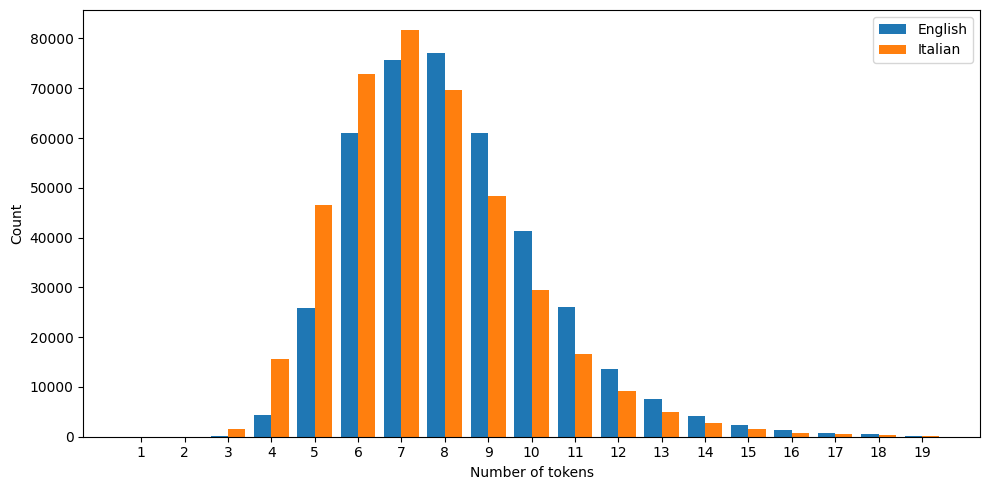

In [22]:
import matplotlib.pyplot as plt

eng_lengths = [len(tokens) for tokens in eng]
ita_lengths = [len(tokens) for tokens in ita]

bins = range(1, 20)
eng_counts = [eng_lengths.count(i) for i in bins]
ita_counts = [ita_lengths.count(i) for i in bins]

x = np.arange(len(bins))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width/2, eng_counts, width, label="English")
ax.bar(x + width/2, ita_counts, width, label="Italian")

ax.set_xticks(x)
ax.set_xticklabels(bins)
ax.set_xlabel("Number of tokens")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

### Vocabulary and Embeddings

Since the dataset consists of pairs of sentences in two different languages, we construct *two separate vocabularies**: one for the source language and one for the target language. With word-level tokenization the number of distinct tokens can grow quite large, since every word form appears as a separate entry. To keep the vocabulary manageable, tokens that occur fewer than two times in the dataset are mapped to a **single unknown token**, denoted "<unk>". In addition to regular words, the vocabulary also includes several **special tokens** used to structure the sequences. One of these is the **beginning-of-sequence token** "<bos>", which marks the start of a target sentence. This token serves as the initial input to the model: it signals that the generation of a new sequence should begin. Morever, since text sequences may have **different lengths**. For computational efficiency, we can still process a minibatch of text sequences at one time by **truncation** and **padding**. Suppose that every sequence in the same minibatch should have the same length. If a text sequence has fewer tokens, we will keep appending the special "<pad>" token to its end. Otherwise, we will truncate the text sequence by only taking its first tokens and discarding the remaining. In this way, every text sequence will have the same length to be loaded in minibatches of the same shape. Furthermore, we also record length of the source sequence excluding padding tokens. 

In [23]:
from collections import Counter

def build_vocab(tokens, min_freq=2,
                special_tokens=['<unk>', '<pad>', '<bos>', '<eos>']):

    counter = Counter(token for sequence in tokens
                            for token in sequence
                            if token not in special_tokens)

    vocab = list(special_tokens) + [
        token for token, freq in counter.most_common()
        if freq >= min_freq
    ]

    token_to_idx = {token: idx for idx, token in enumerate(vocab)}
    idx_to_token = {idx: token for idx, token in enumerate(vocab)}

    return token_to_idx, idx_to_token

The function returns two dictionaries: one mapping tokens to indices (token_to_idx), used to encode sequences before feeding them to the model, and one mapping indices back to tokens (idx_to_token), used to decode the model's predictions into readable text. We build one pair of vocabularies for the source language and one for the target language:



In [24]:
eng_to_idx, idx_to_eng = build_vocab(eng)
ita_to_idx, idx_to_ita = build_vocab(ita)

print(f"English vocabulary size: {len(eng_to_idx)}")
print(f"Italian vocabulary size: {len(ita_to_idx)}")

English vocabulary size: 11726
Italian vocabulary size: 21442


We can use the dictionaries to encode a text sequence into a list of token IDs and to decode a list of token IDs back into a text sequence:

In [25]:
tokens  = ['the', 'cat', '<eos>']
indices = [eng_to_idx.get(t, eng_to_idx['<unk>']) for t in tokens]
decoded = [idx_to_eng[i] for i in indices]

print(tokens)
print(indices)
print(decoded)

['the', 'cat', '<eos>']
[11, 327, 3]
['the', 'cat', '<eos>']


However, an index is just an arbitrary integer number, and there is **no meaningful geometry** in the space of integers (token 42 is not "between" token 41 and 43 in any useful sense). An **embedding layer** fixes this by maintaining a learnable weight matrix:

$\displaystyle E \in \mathbb{R}^{V \times D}$
 
where V is the vocabulary size and D is the embedding dimension. Each row i is the vector representation of the token with index i. Looking up the embedding for a token is simply selecting the corresponding row:

$\displaystyle e(\text{token}_i) = E[i] \in \mathbb{R}^D$ 

This operation is implemented in PyTorch using the "nn.Embedding" layer, which takes care of the lookup. The rows are initialized randomly and then trained end-to-end with the rest of the model, so that **tokens used in similar contexts end up with similar vectors**:

In [26]:
# Size of the vocabulary
V = len(eng_to_idx)

# Select
D = 4 

# Create an embedding layer
E = nn.Embedding(num_embeddings=V, embedding_dim=D)
print("Embedding matrix shape:", E.weight.shape)

# Look up embeddings for two tokens using the existing vocabulary
cat_id = torch.tensor([eng_to_idx["cat"]])
dog_id = torch.tensor([eng_to_idx["dog"]])

cat_embedded = E(cat_id)
dog_embedded = E(dog_id)

print("Embedding of 'cat':", cat_embedded)
print("Embedding of 'dog':", dog_embedded)

Embedding matrix shape: torch.Size([11726, 4])
Embedding of 'cat': tensor([[-0.0232, -0.0111, -0.9953, -0.2994]], grad_fn=<EmbeddingBackward0>)
Embedding of 'dog': tensor([[ 0.4590,  0.5309, -1.3615,  1.9562]], grad_fn=<EmbeddingBackward0>)


For example, after training we would expect the vectors for "cat" and "dog" to be closer to each other than to the vector for "run".

### The Encoder–Decoder Architecture

When we consider the RNN, we introduced the **encoder–decoder architecture** for [sequence-to-sequence learning](./papers/(2014)%20-%20Sequence%20to%20Sequence%20Learning%20with%20Neural%20Networks.pdf) based on two networks. The **encoder** processes the input sequence and transforms it into an internal representation that captures its relevant information. The **decoder** then generates the target sequence one token at a time. At each step, it uses both the representation produced by the encoder and the leftward context of the target sequence (that is, the tokens already generated—to predict the next token):

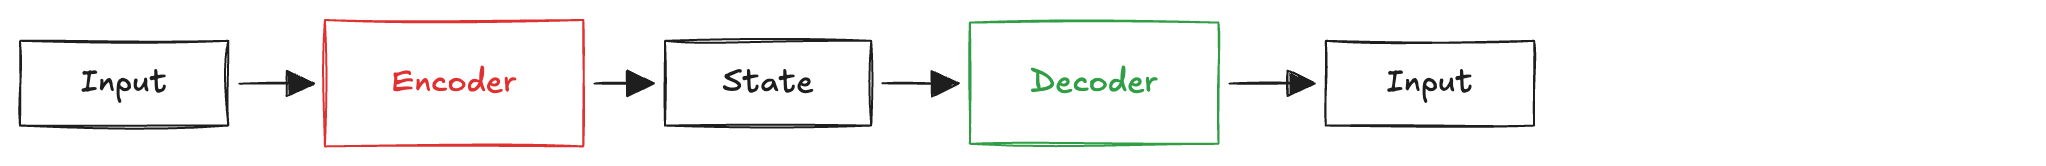

In the machine translation setting, suppose the input sequence in English is the series of tokens "He", "is", "watching", ".". The encoder–decoder architecture first encodes this sequence into an internal representation, capturing the relevant information contained in the sentence. The decoder then uses this representation to generate the translated sentence step by step, producing the output tokens "Egli", "guarda", "." one at a time:

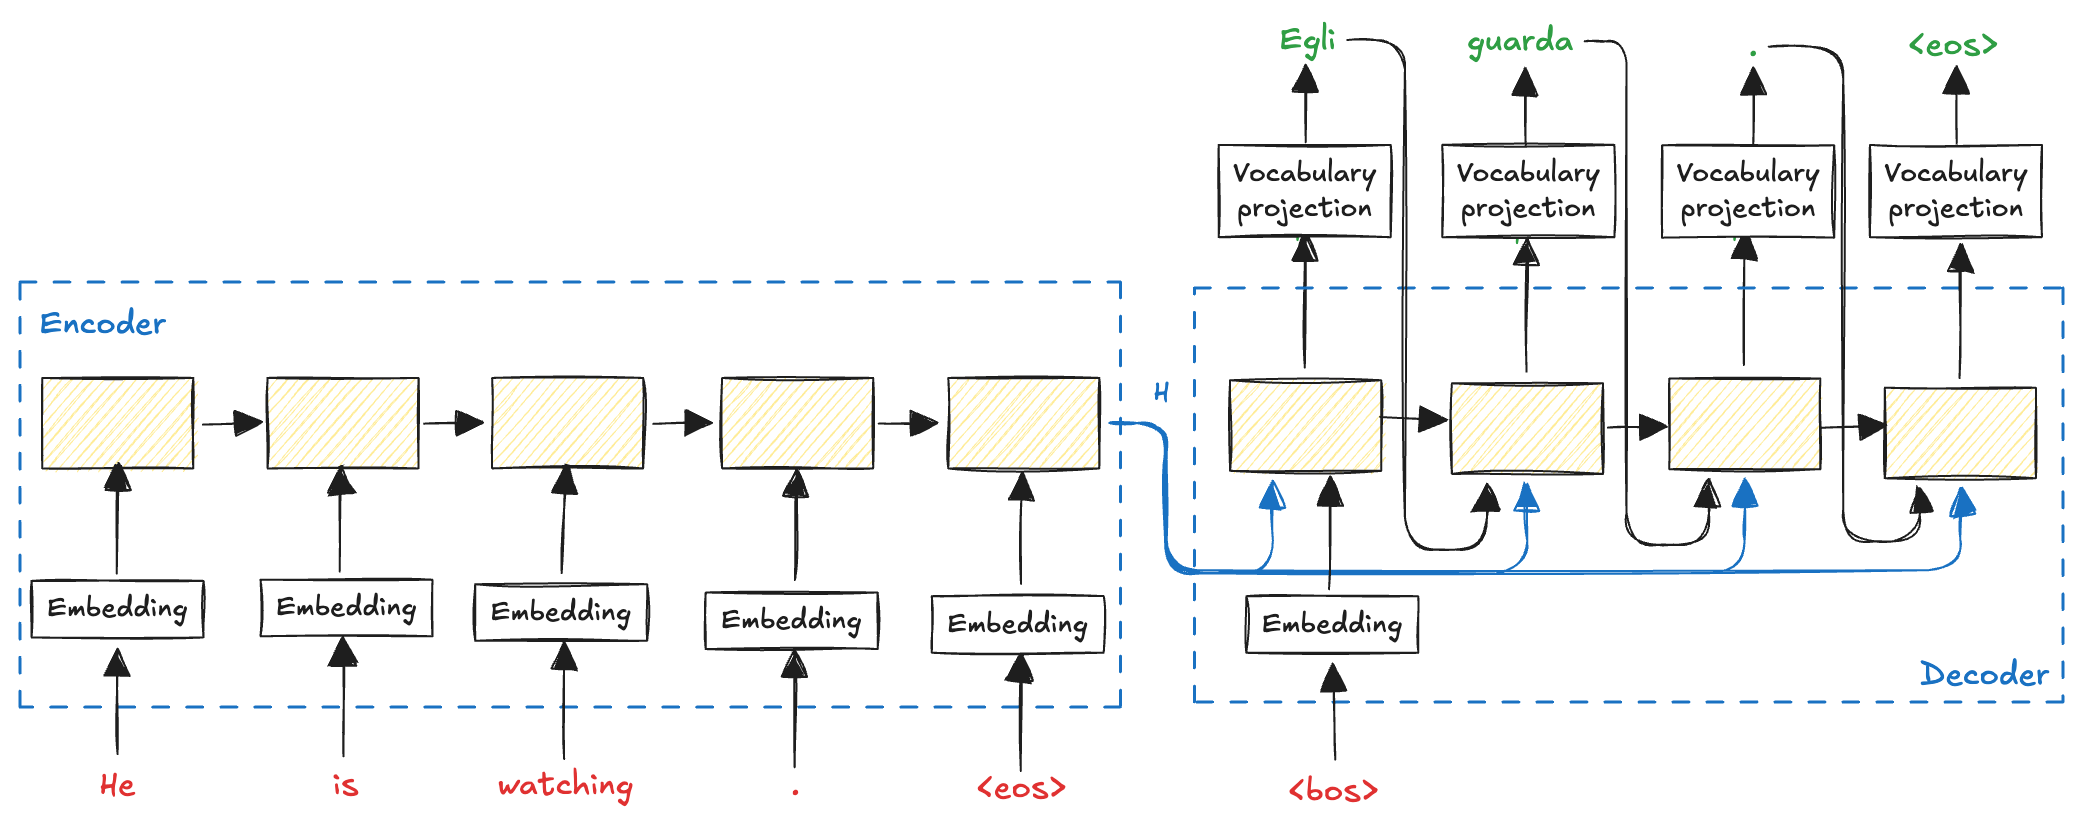

The encoder transforms the input sequence of variable length into a fixed-shape context variable. Consider a single sequence example (batch size 1). Suppose the input sequence is:

$\displaystyle x_1, x_2, ..., x_T$

At each time step t, the RNN calculate the current hidden state:

$\displaystyle h_t = f(x_t, h_{t-1})$

In general, the encoder transforms the collection of hidden states of all time steps into a context variable:

$\displaystyle c = q(h_1, h_2, ..., h_T)$

For example, like in the previous figure, we can simply take the last hidden state of the encoder as the context variable, which is a common choice in many sequence-to-sequence models:

$\displaystyle c = h_T$

More complex architectures can be designed to produce a richer context variable that captures more information about the input sequence. For instance, **bidirectional RNNs** process the input sequence in both forward and backward directions, allowing the context variable to capture information from both past and future tokens. We can implement a simple solution using PyTorch nn.GRU module:

In [27]:
import torch.nn as nn

class Encoder(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)

    # X: (batch, T) — integer token IDs
    def forward(self, X):
        emb = self.embedding(X)        # (batch, T, embed_dim)
        output, state = self.rnn(emb)  # output: (batch, T, hidden_dim)
                                       # state:  (num_layers, batch, hidden_dim)
        return output, state           # context variable c = state[-1]

Several design choices arise when defining the decoder. One possibility is to provide the final hidden state of the encoder to the decoder at every decoding time step, so that the decoder always has direct access to the encoded representation of the input sequence ((as shown in the previous figure). Alternatively, the encoder’s final hidden state can be used only to initialize the decoder’s hidden state at the first decoding step, after which the decoder evolves based on its own internal dynamics. Additional care is required in defining how the inputs and outputs of the decoder are handled during training. A widely used strategy is known as **teacher forcing**. In this approach, the original target sequence is provided to the decoder as input. More precisely, the decoder receives the sequence obtained by concatenating the special beginning-of-sequence token "<bos>" with the target sequence, excluding its final token. The training targets are obtained by shifting the original target sequence by one position. In this way, at each time step the decoder learns to predict the next token in the sequence, given the correct previous token. Importantly, this procedure is possible only during training, since the target sequence is available in the dataset. At inference time, the target sequence is not known in advance. Therefore, the decoder must generate the sequence **autoregressively**. The process starts by feeding the token "<bos>" to the decoder, which predicts the first output token. This predicted token is then used as the input for the next decoding step, and the process continues token by token until the special end-of-sequence token "<eos>" is produced or a maximum length is reached (as shown in the previous figure).

In [28]:
import torch.nn as nn

class Decoder(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    # Y:     (batch, T) — integer token IDs  (<bos> + target[:-1], teacher forcing)
    # state: (num_layers, batch, hidden_dim) — encoder final hidden state (context c)
    def forward(self, Y, state):
        emb = self.embedding(Y)               # (batch, T, embed_dim)
        output, state = self.rnn(emb, state)  # output: (batch, T, hidden_dim)
                                              # state:  (num_layers, batch, hidden_dim)
        logits = self.fc(output)              # (batch, T, vocab_size)
        return logits, state

Putting it all together in code yields the following:

In [29]:
class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    # X: (batch, T_src) — source token IDs
    # Y: (batch, T_tgt) — target token IDs (<bos> + target[:-1], teacher forcing)
    def forward(self, X, Y):
        _, state  = self.encoder(X)       # state: (num_layers, batch, hidden_dim)
        logits, _ = self.decoder(Y, state) # logits: (batch, T_tgt, vocab_size)
        return logits

We compose the complete architecture by combining the encoder and decoder into a single model:

In [30]:
encoder = Encoder(vocab_size=len(eng_to_idx), embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.3)
decoder = Decoder(vocab_size=len(ita_to_idx), embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.3)
seq2seq_model = Seq2Seq(encoder, decoder)

At each decoding step the decoder outputs a **probability distribution over the entire target vocabulary** and it must pick one correct word out of thousands. This is a **multi-class classification problem repeated at every position**, so **cross-entropy loss** is the natural choice: it measures how much probability mass the model assigned to the correct token and penalises it logarithmically when that mass is low. However, sentences in a batch have different lengths: shorter sentences are padded with "<pad>" tokens to match the longest one. For example, if a batch contains the two target sentences "Amo i gatti" (3 tokens) and "Il cane corre velocemente" (4 tokens), the first one becomes ["Amo", "i", "gatti", "<pad>"]. Since the <pad> slot has no correct word to predict, including it in the loss would artificially inflate the number of easy correct predictions and dilute the gradient signal coming from real tokens. We nee to skip those positions entirely, so the model is only penalised and updated based on the actual words it needs to learn to generate. The following 

In [31]:
criterion = nn.CrossEntropyLoss(ignore_index=ita_to_idx['<pad>'])

We optimise all parameters of the encoder and decoder jointly using Adam, a good default choice that adapts the learning rate per parameter automatically, with a standard initial learning rate:

In [32]:
optimizer = torch.optim.Adam(seq2seq_model.parameters(), lr=1e-3)

Before training, it is useful to count the number of **trainable parameters** (all weights and biases that will be updated by the optimiser) to get a sense of the model's capacity and memory footprint:

In [33]:
total_params = sum(p.numel() for p in seq2seq_model.parameters() if p.requires_grad)
print(f"Model parameters:  {total_params:,}")

Model parameters:  25,008,066


With roughly 25 million parameters, the model is moderately sized, most of this comes from the two embedding layers (one per language) and the stacked LSTM weights. It is large enough to capture meaningful translation patterns on this dataset, but small enough to train in reasonable time on amodest GPU.

### Dataset and DataLoader

We now **wrap the data into a PyTorch Dataset**, that handles all responsibilities at once: **token-to-index encoding** (converting each word to its integer id, replacing unknowns, and padding shorter sentences), and **teacher forcing alignment** (shifting the target sequence to create the decoder inputs and training targets). The Dataset returns pairs of source and target sequences ready to be fed into the model:

In [34]:
from torch.utils.data import Dataset, DataLoader, random_split

class TranslationDataset(Dataset):

    def __init__(self, src_sequences, tgt_sequences, src_vocab, tgt_vocab,
                 max_src_len=20, max_tgt_len=20):
        self.tgt_bos = tgt_vocab['<bos>']
        self.src     = self._encode(src_sequences, src_vocab, max_src_len)
        self.tgt     = self._encode(tgt_sequences, tgt_vocab, max_tgt_len)

    def _encode(self, sequences, vocab, max_len):
        unk, pad = vocab['<unk>'], vocab['<pad>']
        ids = []
        for seq in sequences:
            seq_ids  = [vocab.get(t, unk) for t in seq][:max_len]
            seq_ids += [pad] * (max_len - len(seq_ids))
            ids.append(seq_ids)
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        src     = self.src[idx]                                         # (max_src_len,)
        tgt     = self.tgt[idx]                                         # (max_tgt_len,)
        dec_in  = torch.cat([torch.tensor([self.tgt_bos]), tgt[:-1]])   # <bos> + tgt[:-1]
        dec_out = tgt                                                   # target
        return src, dec_in, dec_out


We instantiate the dataset from the full corpus and then split it into a training set (90%) and a validation set (10%), as usual the training set is used to update the model's weights, while the validation set is held out to monitor generalisation and detect overfitting during training:

In [35]:
eng_ita_dataset    = TranslationDataset(eng, ita, eng_to_idx, ita_to_idx)
eng_ita_train_size = int(0.9 * len(eng_ita_dataset))
eng_ita_val_size   = len(eng_ita_dataset) - eng_ita_train_size
eng_ita_train_set, eng_ita_val_set = random_split(eng_ita_dataset, [eng_ita_train_size, eng_ita_val_size])

print(f"Training samples:   {eng_ita_train_size:,}")
print(f"Validation samples: {eng_ita_val_size:,}")

Training samples:   363,129
Validation samples: 40,348


We can create a **DataLoader** to handle **batching** and **shuffling** of the data during training:

In [36]:
eng_ita_train_loader = DataLoader(eng_ita_train_set, batch_size=128, shuffle=True)
eng_ita_val_loader   = DataLoader(eng_ita_val_set,   batch_size=128, shuffle=False)

### Training loop

We now train the model for some epochs, in order to speed up training, we can use a GPU or MPS if available:

In [37]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
seq2seq_model = seq2seq_model.to(device)
print(f"Using device: {device}")

Using device: mps


The training function iterates over all batches in the loader: for each batch it moves the tensors to the target device, performs a forward pass to obtain the logits, flattens them to compute the cross-entropy loss, then backpropagates the gradients (clipping their norm to 1.0 to prevent exploding gradients, a common instability in RNNs) and finally updates the weights with the optimiser; the function returns the average loss per batch across the whole epoch:

In [38]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for src, dec_in, dec_out in loader:
        src, dec_in, dec_out = src.to(device), dec_in.to(device), dec_out.to(device)
        optimizer.zero_grad()
        logits = model(src, dec_in)                                # (batch, T, vocab_size)
        loss   = criterion(logits.reshape(-1, logits.size(-1)), dec_out.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

The evaluation function mirrors the training loop but with two key differences: model.eval() switches off dropout and other training-specific behaviours, and torch.no_grad() disables gradient computation entirely (since no weight update is needed) making the validation pass faster and more memory-efficient:

In [39]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, dec_in, dec_out in loader:
            src, dec_in, dec_out = src.to(device), dec_in.to(device), dec_out.to(device)
            logits = model(src, dec_in)
            loss   = criterion(logits.reshape(-1, logits.size(-1)), dec_out.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

We run the training loop for 15 epochs, recording the train and validation loss at each step so we can later plot the learning curves and visually inspect whether the model is learning steadily, overfitting, or underfitting. Since the trainig process can be time-consuming, we can also save the model, so that we can resume ita later if needed without having to start from scratch:

In [40]:
import os

MODEL_PATH = "./data/seq2seq_model.pt"

if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    seq2seq_model.load_state_dict(checkpoint["model_state"])
    train_losses = checkpoint["train_losses"]
    val_losses   = checkpoint["val_losses"]
    num_epochs   = len(train_losses)
    seq2seq_model.eval()
    print(f"Model loaded from {MODEL_PATH}")
else:
    num_epochs = 15
    train_losses, val_losses = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss = train(seq2seq_model, eng_ita_train_loader, optimizer, criterion, device)
        val_loss   = evaluate(seq2seq_model, eng_ita_val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}", end='\r', flush=True)

    torch.save({
        "model_state":  seq2seq_model.state_dict(),
        "train_losses": train_losses,
        "val_losses":   val_losses,
    }, MODEL_PATH)
    print(f"\nModel saved to {MODEL_PATH}")

Epoch 15 | train loss 0.4959 | val loss 0.8013
Model saved to ./data/seq2seq_model.pt


We plot the learning curves (training and validation loss over epochs) to visually diagnose the training dynamics: ideally both curves should decrease steadily and converge close together; a large and growing gap between them would signal **overfitting**, while both curves remaining high would suggest **underfitting**:

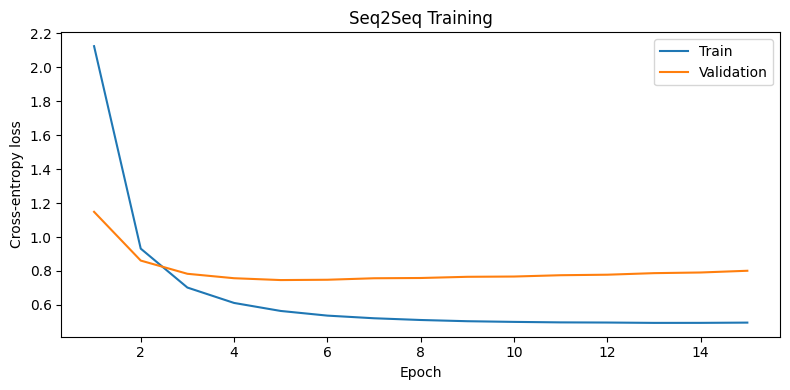

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, num_epochs + 1), train_losses, label='Train')
ax.plot(range(1, num_epochs + 1), val_losses,   label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Seq2Seq Training')
ax.legend()
plt.tight_layout()
plt.show()

Both losses drop sharply in the first two epochs, then the training loss continues to decrease slowly and steadily while the validation loss flattens. The growing gap between the two curves is a mild sign of overfitting (the model keeps improving on the training data but stops generalising beyond epoch 3 or so). Techniques such as early stopping, stronger dropout, or reducing the model capacity could help close this gap.

### Prediction

During inference, **the target sequence is not available**, so the decoder cannot rely on the true previous token as it does during training with teacher forcing. Instead, the sequence must be generated **autoregressively**. At each time step, the decoder receives as input the token that it predicted at the previous step, rather than the ground-truth token. The generation process begins by feeding the special beginning-of-sequence token "<bos>" into the decoder at the first time step. The decoder then produces a probability distribution over the target vocabulary, and a **simple decoding strategy is to select the token with the highest probability**. This predicted token is used as the input for the next decoding step, and the procedure continues iteratively. The generation stops when the decoder produces the special end-of-sequence token "eos", indicating that the output sequence is complete.

In [42]:
def predict(model, src_sequence, eng_to_idx, ita_to_idx, idx_to_ita, max_len=20, device='cpu'):
    model.eval()
    with torch.no_grad():

        # encode the source sequence
        unk, pad = eng_to_idx['<unk>'], eng_to_idx['<pad>']
        src_ids  = [eng_to_idx.get(t, unk) for t in src_sequence][:max_len]
        src_ids += [pad] * (max_len - len(src_ids))
        src      = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

        # encode and initialise the decoder hidden state
        _, h = model.encoder(src)

        # start decoding from <bos>
        token     = torch.tensor([[ita_to_idx['<bos>']]], dtype=torch.long).to(device)
        output    = []

        for _ in range(max_len):
            logits, h = model.decoder(token, h)   # (1, 1, vocab_size)
            token     = logits.argmax(dim=-1)      # greedy decoding
            word      = idx_to_ita[token.item()]
            if word == '<eos>':
                break
            output.append(word)

    return output

In [43]:
examples = [
    ["i", "love", "you", "."],
    ["the", "cat", "is", "on", "the", "table", "."],
    ["where", "is", "the", "train", "station", "?"],
    ["good", "morning", "!"],
    ["she", "reads", "a", "book", "every", "day", "."],
    ["we", "are", "happy", "."],
    ["what", "time", "is", "it", "?"],
    ["can", "you", "help", "me", "?"],
    ["this", "is", "a", "test", "."],
]

for src in examples:
    translation = predict(seq2seq_model, src, eng_to_idx, ita_to_idx, idx_to_ita, device=device)
    print(f"  EN: {' '.join(src)}")
    print(f"  IT: {' '.join(translation)}")
    print()

  EN: i love you .
  IT: ti amo .

  EN: the cat is on the table .
  IT: il gatto è sul tavolo .

  EN: where is the train station ?
  IT: dov ' è la stazione ferroviaria ?

  EN: good morning !
  IT: buongiorno !

  EN: she reads a book every day .
  IT: legge ogni libro ogni giorno .

  EN: we are happy .
  IT: noi siamo felici .

  EN: what time is it ?
  IT: che ore sono ?

  EN: can you help me ?
  IT: mi puoi aiutare ?

  EN: this is a test .
  IT: questo è un esame .



### Evaluation

We can evaluate a predicted sequence by comparing it with the target sequence (the ground truth). But what precisely is the appropriate measure for comparing similarity between two sequences? **Bilingual Evaluation Understudy** (BLEU), was originally proposed for evaluating machine translation results and it has been extensively used in measuring the quality of output sequences across many applications. We need the notion of an **n-gram**, a contiguous subsequence of exactly n tokens. Given the sentence: 

"the cat is on the mat" 

Its 1-grams (unigrams), 2-grams (bigrams), and 3-grams (trigrams) are:

- 1-grams: "the", "cat", "is", "on", "the", "mat"
- 2-grams: "the cat", "cat is", "is on", "on the", "the mat"
- 3-grams: "the cat is", "cat is on", "is on the", "on the mat"

Longer n-grams **capture more context** and impose **stricter local ordering constraints**. The core idea of BLEU is to check, for each n-gram in the predicted sequence, whether it also appears in the target sequence. Formally, we degfine the **n-gram precision** has the number of n-grams in the predicted sequence that also appear in the target sequence, divided by the total number of n-grams in the predicted sequence:

$\displaystyle p_n = \frac{\sum_{\mathbf{s} \in G_n(\hat{\mathbf{y}})} \min\!\left(c(\mathbf{s},\hat{\mathbf{y}}),\, c(\mathbf{s}, \mathbf{y})\right)}{\sum_{\mathbf{s} \in G_n(\hat{\mathbf{y}})} c(\mathbf{s}, \hat{\mathbf{y}})}$

where G is the set of distinct n-grams in a sentence, and c() is the number of times and n-grams occurs in a sentence. The min() function in the numerator is a **clipping mechanism**: it prevents artificially inflating the score by repeating a correct token many times (e.g., predicting "the the the the" would not be rewarded beyond how many times "the" appears in the reference). Here an implementation in Python:

In [44]:
from collections import Counter

def ngram_precision(prediction, target, n):
    pred_ngrams   = Counter(tuple(prediction[i:i+n]) for i in range(len(prediction) - n + 1))
    target_ngrams = Counter(tuple(target[i:i+n])     for i in range(len(target)     - n + 1))
    clipped       = sum(min(c, target_ngrams[s]) for s, c in pred_ngrams.items())
    total         = sum(pred_ngrams.values())
    return clipped / total if total > 0 else 0.0

In the example, if the predicted sequence is 

"the cat is on the roof"

We can compute each precision as follows:

| n | Matched n-grams | $p_n$ |
|---|---|---|
| 1 | "the", "cat", "is", "on", "the" → 5 of 6 | $5/6$ |
| 2 | "the cat", "cat is", "is on", "on the" → 4 of 5 | $4/5$ |
| 3 | "the cat is", "cat is on", "is on the" → 3 of 4 | $3/4$ |
| 4 | "the cat is on", "cat is on the" → 2 of 3 | $2/3$ |

Higher-order precisions drop because the mismatch ("roof" vs "mat") contaminates longer windows. The example above works well partly because the two sequences have the same length. But what if the predicted sequence were much shorter — say, just "the"? That single word does appear in the reference, giving a perfect unigram precision despite predicting almost nothing. Precision rewards for every word we **get right**, but it never asks what we **missed**. The natural fix would be to also measure **recall** (how much of the reference we covered), but recall is awkward when there are multiple valid references of different lengths. BLEU takes a simpler route: it does not measure recall directly, but it **penalises predictions that are suspiciously short**. The intuition is that a much shorter translation is very likely omitting important content, regardless of how precise its words are. This is captured by the **brevity penalty**:

$\displaystyle \mathrm{BP} = \begin{cases} 1 & \text{if } |\hat{\mathbf{y}}| \geq |\mathbf{y}| \\ \exp\!\left(1 - \dfrac{|\mathbf{y}|}{|\hat{\mathbf{y}}|}\right) & \text{if } |\hat{\mathbf{y}}| < |\mathbf{y}| \end{cases}$

When the prediction is at least as long as the reference there is no penalty. As the prediction shrinks, the brevity penalty decays smoothly toward 0, proportionally discounting the precision scores, the shorter the prediction relative to the reference, the harsher the penalty. Here a Python implementation:

In [45]:
import math

def brevity_penalty(predictions, targets):
    pred_len   = sum(len(pred) for pred in predictions)
    target_len = sum(len(tgt)  for tgt  in targets)
    if pred_len >= target_len:
        return 1.0
    return math.exp(1 - target_len / pred_len)

ombining precisions across n-gram with the brevity penalty gives the final BLEU score:

$\displaystyle \text{BLEU} = \mathrm{BP} \cdot \exp\!\left(\sum_{n=1}^{N} \frac{1}{N} \log p_n\right)$

Notice that we are averaging the precision values using logarithms and exponentials, which is equivalent to taking the **geometric mean** of the precisions rather than the arithmetic mean. Unlike the arithmetic mean, which averages values additively, the geometric mean multiplies them, so a single near-zero precisione drags the whole product toward zero, no matter how well the other orders perform. This ensures that a catastrophically low score at any single order drags the overall score down significantly, so the model cannot ignore any level of matching.

In [46]:
def bleu(predictions, targets, N=4):
    
    bp = brevity_penalty(predictions, targets)
    
    p_log_sum = 0.0

    for n in range(1, N + 1):
        matched, total = 0, 0
        for pred, tgt in zip(predictions, targets):
            pred_ngrams   = Counter(tuple(pred[i:i+n]) for i in range(len(pred) - n + 1))
            target_ngrams = Counter(tuple(tgt[i:i+n])  for i in range(len(tgt)  - n + 1))
            matched      += sum(min(c, target_ngrams[s]) for s, c in pred_ngrams.items())
            total        += sum(pred_ngrams.values())
        pn         = matched / total if total > 0 else 0.0
        p_log_sum += (1 / N) * math.log(pn) if pn > 0 else float('-inf')

    return bp * math.exp(p_log_sum)

A BLEU score of 1 indicates a perfect match with the reference; a score of 0 means no n-gram overlaps at any order. We can think of BLEU as asking, at each level of detail: how much of what the model said also appears in the reference? Short n-grams are easier to match and capture **vocabulary accuracy**. Long n-grams are harder to match and capture whether the model **preserves correct phrasing**. We now iterate over the validation set, generate a prediction for each source sentence, collect the results, and compute the corpus-level BLEU score:

In [47]:
targets, predictions = [], []

for idx in eng_ita_val_set.indices:
    src  = eng[idx][:-1]
    ref  = ita[idx][:-1]
    pred = predict(
        seq2seq_model, src,
        eng_to_idx, ita_to_idx, idx_to_ita,
        device=device
    )
    targets.append(ref)
    predictions.append(pred)

seq2seq_bleu = bleu(predictions, targets, N=4)

print(f"BLEU: {seq2seq_bleu:.4f}")

BLEU: 0.4998


This score means that roughly half of the n-grams in the predicted translations overlap with the reference. For a relatively simple RNN-based model trained on short sentence pairs, this is a reasonable result.

## Overcoming the bottleneck

The encoder–decoder architecture suffers from a **fundamental limitation**. In its basic form, the encoder compresses all the information contained in the input sequence into a single fixed-dimensional representation. This representation is then passed to the decoder, which relies on it as the sole source of information for generating the output sequence. In this sense, the intermediate state is implicitly treated as a **sufficient statistic** of the entire input:

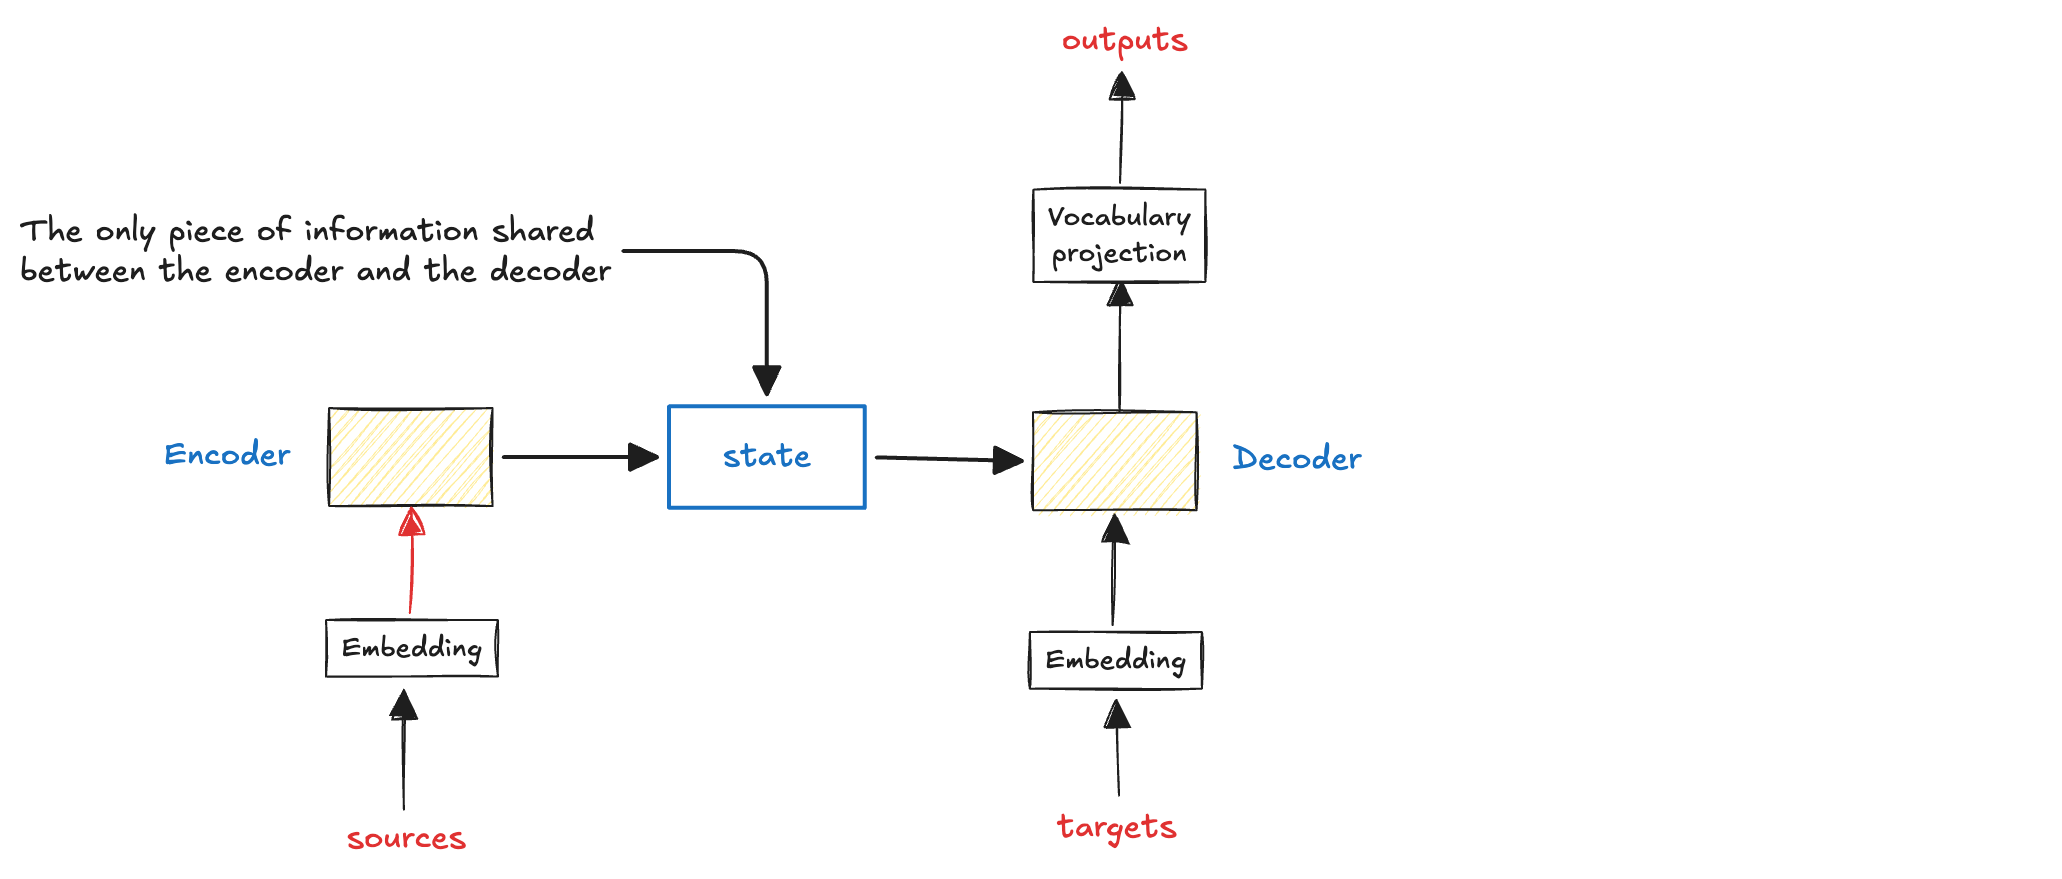

While this abstraction is **reasonable when the input is short** and the amount of information to be retained is limited, it becomes problematic as the input grows in length or complexity. It arises whenever the input is structured, variable in size, or information-rich, such as long sentences, audio signals, or high-resolution images. A fixed-size representation must compress all relevant details into a limited number of dimensions, inevitably leading to information loss. As a result, the decoder is forced to **operate on an incomplete summary of the input**, which can degrade performance.

### Adding attention

This limitation naturally leads to the introduction of **attention mechanisms**, which can help in learning **alignment** between the input and the output. When translating a sentence, a human reader does not rely on a single compressed summary of the entire input. Instead, while generating each word, they implicitly attend to **specific parts** of the source sentence that are **most relevant** at that moment. For instance, when producing a verb, the focus typically shifts to the corresponding verb in the source, when generating a noun, attention aligns with the appropriate noun. In this sense, translation involves a **dynamic, context-dependent correspondence** between positions in the input and positions in the output. The key idea behind attention is to make this notion of alignment learnable and differentiable. Rather than forcing the decoder to depend on a single fixed representation, [the model is allowed to revisit the entire input sequence at every decoding step](./papers/(2015)%20-%20Neural%20Machine%20Translation%20by%20Jointly%20Learning%20to%20Align%20and%20Translate.pdf).When predicting the next token, the decoder computes a set of weights over the input positions, determining how much attention to pay to each part of the source sequence. These weights define a soft alignment and are used to form a context vector, which aggregates the most relevant information for the current prediction:

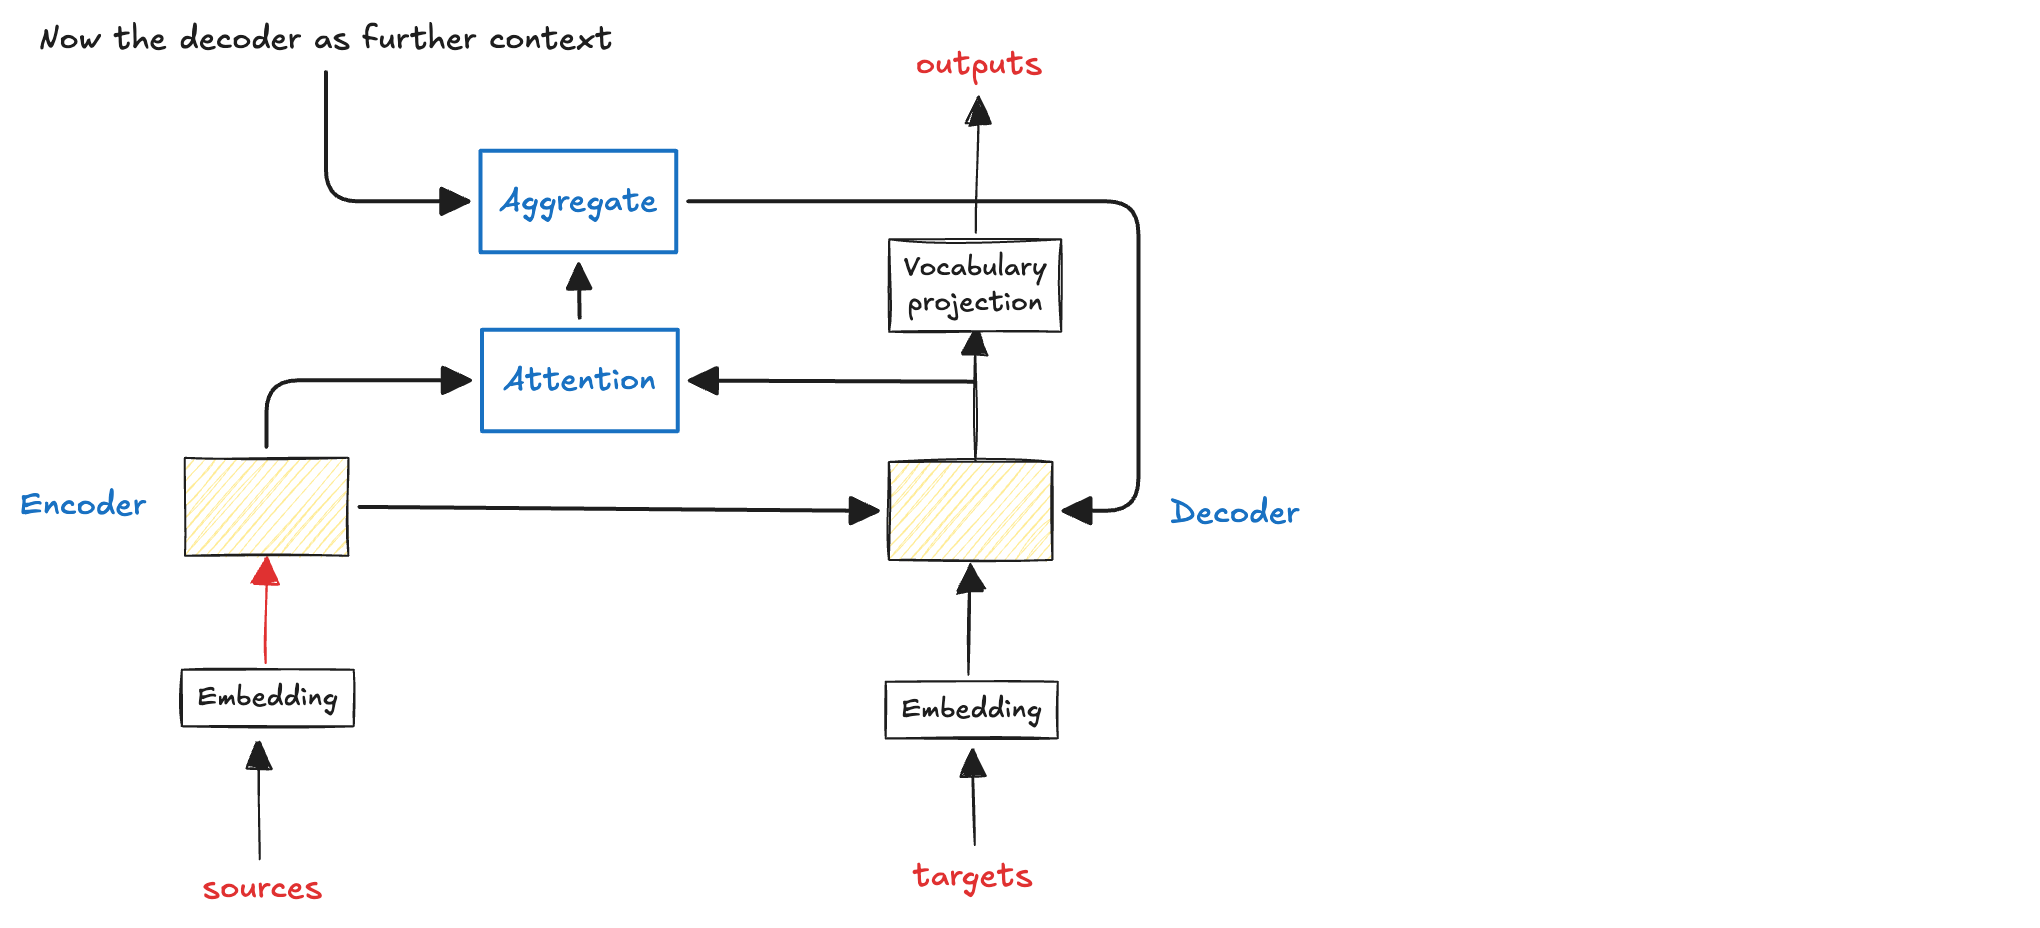

Concretely, instead of a fixed context variable:

$\displaystyle c = h_T$

with attention, the state becomes dynamic, at each deconding step t it is recomputed as a weighted combination of all encoder hidden states:

$\displaystyle c_t = \sum_{i=1}^{T} \alpha_{t,i} h_i$

The weights measure how relevant each position of the source (i) is for generating the token at each positions of the target (t). The score that produce the weights can be any of the scoring functions we have discussed, where the query is the decoder's previous hidden state (s) and keys and values are the encoder's hidden states (h):

$\displaystyle e_{t,i} = w_0^\top \tanh\!\big(W_q s_{t-1} + W_k h_i\big)$

For exaample, we can use the additive score to compute the attention weights:

$\displaystyle \alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_{j=1}^{T} \exp(e_{t,j})}$

Our current implementation of the encoder already returns both the output and the state, so it can be used as it is:

In [48]:
output, state = encoder(torch.tensor([[eng_to_idx['the'], 
                                       eng_to_idx['cat'], 
                                       eng_to_idx['sat']]]).to(device))

# output: (batch, T, hidden_dim)  ← all h_t, now we use these
# state:  (num_layers, batch, hidden_dim)  ← only h_T, used so f

The decoder needs to be modified to compute the attention weights and the context vector at each decoding step, and to use the context vector as an additional input when predicting the next token:

In [49]:
class AttentionDecoder(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # attention module to compute context vector c_t at each step
        self.attention = AdditiveAttention(d_q=hidden_dim, d_k=hidden_dim, h=hidden_dim)
        
        # input = embedding + context vector concatenated
        self.rnn = nn.GRU(embed_dim + hidden_dim, hidden_dim, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, Y, state, enc_output):

        # calculate the embedding of the input tokens
        emb = self.embedding(Y)             

        # baffer to store the output of each time step
        outputs = []

        # iterate over the time steps of the target sequence
        for t in range(emb.shape[1]):

            # the query is the last output of the decoder
            query   = state[-1].unsqueeze(1)           

            # Keys and values are the encoder outputs at all time steps
            context = self.attention(query, enc_output, enc_output)

            # concatenate embedding and context
            rnn_input = torch.cat([emb[:, t:t+1, :], context], dim=-1)  

            # pass through the RNN and update the state
            output, state = self.rnn(rnn_input, state)    

            # store the output for this time step                  
            outputs.append(output)

        # concatenate the outputs of all time steps
        outputs = torch.cat(outputs, dim=1)

        # pass through the final fully connected layer 
        logits  = self.fc(outputs)

        # return the logits and the final state
        return logits, state

We now wrap encoder and decoder into a single module, mirroring the structure of Seq2Seq, but passing the full sequence of encoder hidden states to the decoder at every step, so that attention can dynamically compute a context vector rather than relying on the fixed final state:

In [50]:
class AttentionSeq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, X, Y):
        # encode the source sequence and get the encoder outputs and final state
        enc_output, state = self.encoder(X)

        # decode the target sequence using the encoder outputs for attention
        logits, _         = self.decoder(Y, state, enc_output)

        # return the logits
        return logits

The following prediction function mirrors the one used for the baseline model, with two differences: the encoder output is passed to the decoder at every step to enable attention, and after each decoding step we collect the attention weights, returning them stacked as a matrix that we can use to visualise which source tokens the model focused on when generating each target token:

In [51]:
def attention_predict(model, src_sequence, eng_to_idx, ita_to_idx, idx_to_ita, max_len=20, device='cpu'):
    model.eval()
    with torch.no_grad():

        unk, pad = eng_to_idx['<unk>'], eng_to_idx['<pad>']
        src_ids  = [eng_to_idx.get(t, unk) for t in src_sequence][:max_len]
        src_ids += [pad] * (max_len - len(src_ids))
        src = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

        enc_output, h = model.encoder(src)

        token       = torch.tensor([[ita_to_idx['<bos>']]], dtype=torch.long).to(device)
        output      = []
        all_weights = []

        for _ in range(max_len):
            logits, h = model.decoder(token, h, enc_output)
            token     = logits.argmax(dim=-1)
            word      = idx_to_ita[token.item()]
            if word == '<eos>':
                break
            output.append(word)
            all_weights.append(model.decoder.attention.weights.squeeze().cpu())

    return output, torch.stack(all_weights, dim=0)  # (T_tgt, T_src)

We instantiate the attention model with the same hyperparameters used for the baseline, so that any difference in performance can be attributed to the attention mechanism rather than to a larger or different architecture:

In [52]:
attention_encoder = Encoder(vocab_size=len(eng_to_idx), embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.3)
attention_decoder = AttentionDecoder(vocab_size=len(ita_to_idx), embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.3)
attention_model     = AttentionSeq2Seq(attention_encoder, attention_decoder).to(device)

attention_optimizer = torch.optim.Adam(attention_model.parameters(), lr=1e-3)

In [53]:
total_params = sum(p.numel() for p in attention_model.parameters() if p.requires_grad)
print(f"Attention model parameters: {total_params:,}")

Attention model parameters: 26,319,810


We train the attention model for some epochs using the same procedure, optimizer, and criterion as the baseline, caching the weights and loss curves to disk so that subsequent runs skip training and reload the checkpoint directly:

In [55]:
ATT_MODEL_PATH = "./data/attention_seq2seq_model.pt"

if os.path.exists(ATT_MODEL_PATH):
    checkpoint         = torch.load(ATT_MODEL_PATH, map_location=device)
    attention_model.load_state_dict(checkpoint["model_state"])
    attention_train_losses   = checkpoint["train_losses"]
    attention_val_losses     = checkpoint["val_losses"]
    attention_num_epochs     = len(attention_train_losses)
    attention_model.eval()
    print(f"Model loaded from {ATT_MODEL_PATH}")
else:
    attention_num_epochs   = 15
    attention_train_losses, attention_val_losses = [], []

    for epoch in range(1, attention_num_epochs + 1):
        train_loss = train(attention_model, eng_ita_train_loader, attention_optimizer, criterion, device)
        val_loss   = evaluate(attention_model, eng_ita_val_loader, criterion, device)

        attention_train_losses.append(train_loss)
        attention_val_losses.append(val_loss)

        print(f"Epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}", end='\r', flush=True)

    torch.save({
        "model_state":  attention_model.state_dict(),
        "train_losses": attention_train_losses,
        "val_losses":   attention_val_losses,
    }, ATT_MODEL_PATH)
    
    print(f"\nModel saved to {ATT_MODEL_PATH}")

Epoch 15 | train loss 0.6195 | val loss 0.7775
Model saved to ./data/attention_seq2seq_model.pt


We plot the training and validation loss curves for both models side by side, sharing the y-axis to make the comparison direct:

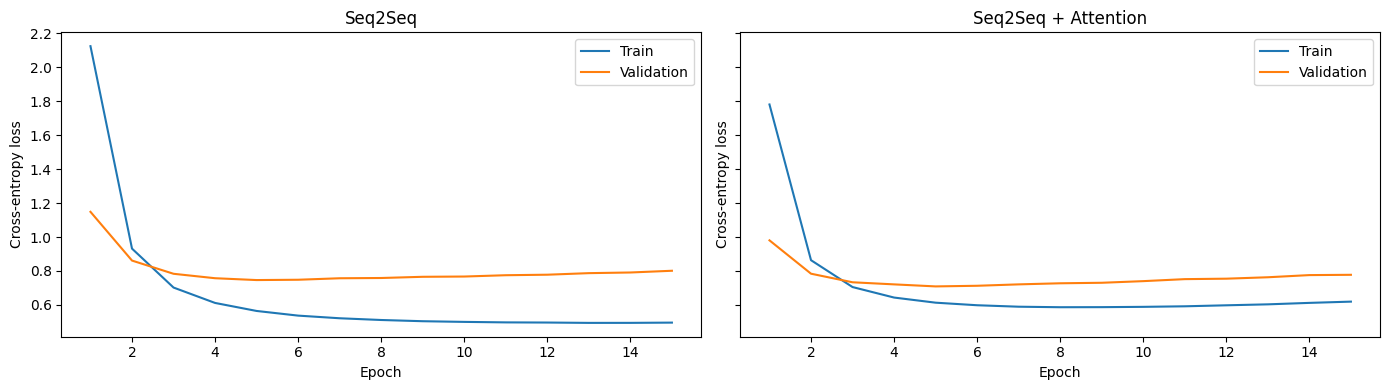

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, tr, va, ne, title in [
    (axes[0], train_losses, val_losses, num_epochs, 'Seq2Seq'),
    (axes[1], attention_train_losses, attention_val_losses, attention_num_epochs, 'Seq2Seq + Attention'),
]:
    ax.plot(range(1, ne + 1), tr, label='Train')
    ax.plot(range(1, ne + 1), va, label='Validation')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend()

plt.tight_layout()
plt.show()

Both models converge quickly within the first few epochs and then plateau. The baseline shows a wider and growing gap between train and validation loss, a sign of mild overfitting. The attention model keeps the two curves closer together for longer, suggesting that **the additional context acts as a regulariser**.

We prepare a prediction function which mirrors the one used for the baseline model, with two differences: the encoder output is passed to the decoder at every step to enable attention, and after each decoding step we collect the attention weights, returning them stacked as a matrix that we can use to visualise which source tokens the model focused on when generating each target token:

In [62]:
def attention_predict(model, src_sequence, eng_to_idx, ita_to_idx, idx_to_ita, max_len=20, device='cpu'):
    model.eval()
    with torch.no_grad():
        unk, pad = eng_to_idx['<unk>'], eng_to_idx['<pad>']
        src_ids  = [eng_to_idx.get(t, unk) for t in src_sequence][:max_len]
        src_ids += [pad] * (max_len - len(src_ids))
        src      = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

        enc_output, h = model.encoder(src)

        token, output, all_weights = torch.tensor([[ita_to_idx['<bos>']]], dtype=torch.long).to(device), [], []

        for _ in range(max_len):
            logits, h = model.decoder(token, h, enc_output)
            token     = logits.argmax(dim=-1)
            word      = idx_to_ita[token.item()]
            if word == '<eos>':
                break
            output.append(word)
            all_weights.append(model.decoder.attention.weights.squeeze().cpu())

    return output, torch.stack(all_weights, dim=0)  # (T_tgt, T_src)

We evaluate the model on the validation set using the same BLEU metric computed earlier, so we can directly compare translation quality before and after introducing attention:

In [ ]:
targets, attention_preds = [], []

for idx in eng_ita_val_set.indices:
    src  = eng[idx][:-1]
    ref  = ita[idx][:-1]
    pred, _ = attention_predict(
        attention_model, src,
        eng_to_idx, ita_to_idx, idx_to_ita,
        device=device
    )
    targets.append(ref)
    attention_preds.append(pred)

attention_bleu = bleu(attention_preds, targets, N=4)

print(f"Seq2Seq BLEU: {seq2seq_bleu:.4f}")
print(f"Attention BLEU: {attention_bleu:.4f}")

Seq2Seq BLEU: 0.4998
Attention BLEU: 0.5053


The attention model scores marginally higher, but the difference is negligible. This is not surprising: the dataset consists mostly of short sentences where a fixed context vector is already sufficient, so the dynamic has little room to show its advantage. Attention becomes significantly more impactful on longer, more complex sequences. Beyond aggregate metrics, we can inspect a few hand-picked sentences to get a qualitative feel for where attention helps and where both models still struggle:

In [64]:
examples = [
    ["i", "love", "you", "."],
    ["the", "cat", "is", "on", "the", "table", "."],
    ["where", "is", "the", "train", "station", "?"],
    ["she", "reads", "a", "book", "every", "day", "."],
]

for src in examples:
    base = predict(seq2seq_model, src, eng_to_idx, ita_to_idx, idx_to_ita, device=device)
    attention, _ = attention_predict(attention_model, src, eng_to_idx, ita_to_idx, idx_to_ita, device=device)
    print(f"  EN:                  {' '.join(src)}")
    print(f"  Seq2Seq:             {' '.join(base)}")
    print(f"  Seq2Seq + Attention: {' '.join(attention)}")
    print()

  EN:                  i love you .
  Seq2Seq:             ti amo .
  Seq2Seq + Attention: io ti amo .

  EN:                  the cat is on the table .
  Seq2Seq:             il gatto è sul tavolo .
  Seq2Seq + Attention: il gatto è sul tavolo .

  EN:                  where is the train station ?
  Seq2Seq:             dov ' è la stazione ferroviaria ?
  Seq2Seq + Attention: dov ' è la stazione dei treni ?

  EN:                  she reads a book every day .
  Seq2Seq:             legge ogni libro ogni giorno .
  Seq2Seq + Attention: legge un libro ogni giorno .



Both models perform similarly on simple, short sentences, where the fixed context vector already captures enough information. The difference emerges on slightly harder cases: for "she reads a book every day" the baseline produces the **hallucinated** "ogni libro" (every book) instead of "un libro" (a book), while attention corrects it by being able to focus on "a" independently when generating that token. Overall the qualitative improvement is modest, consistent with what the BLEU scores showed: attention helps at the margin but the task remains well within reach of the baseline for short, frequent sentences. Finally, we create a function to **visualise the weight matrix**, letting us inspect which source tokens the decoder attended to when generating each target word:

In [75]:
def show_attention(matrix, src_tokens, tgt_tokens):
    fig, ax = plt.subplots(figsize=(len(src_tokens) * 0.9, len(tgt_tokens) * 0.9 + 1))

    pcm = ax.imshow(matrix.detach().numpy(), cmap='Blues')

    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens)

    ax.set_xlabel('Source (keys)')
    ax.set_ylabel('Target (queries)')
    ax.set_title('Attention weights')

    fig.colorbar(pcm, ax=ax, shrink=0.3)
    plt.tight_layout()
    plt.show()

We run the prediction on a simple sentence and pass the returned weight matrix directly to function to produce the heatmap:

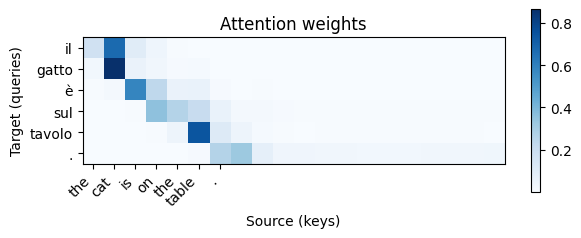

In [79]:
src = ["the", "cat", "is", "on", "the", "table", "."]

translation, weights = attention_predict(
    attention_model, src, eng_to_idx, ita_to_idx, idx_to_ita, device=device
)

show_attention(weights, src_tokens=src, tgt_tokens=translation)

The heatmap shows a clear near-diagonal pattern: each Italian token attends most strongly to its direct English counterpart ("gatto" and "cat", "è" and "is", "tavolo" and "table") which is expected for a language pair as close as English and Italian. The most notable deviation is "il", which spreads attention across both "the" and "cat", reflecting the fact that the Italian definite article must agree with the noun it precedes and so the model looks ahead to determine gender.

### Self-attention

## The transformer architecture